In [1]:
from cosipy import BinnedData, UnBinnedData#, COSILike
from cosipy.spacecraftfile import SpacecraftFile
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.response.PointSourceResponse import PointSourceResponse

from COSILikeNew import COSILike

from scoords import SpacecraftFrame

import astropy.units as u
import astropy.constants as const
from astropy.coordinates import SkyCoord, Galactic

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cycler
from scipy.optimize import curve_fit, minimize
from scipy.signal import find_peaks
import pandas as pd
from lmfit import Model
from lmfit.models import GaussianModel

from threeML import Line, Gaussian, Cauchy, PointSource, Model, JointLikelihood, DataList
from astromodels import Parameter
from histpy import Histogram, Axes, Axis, HealpixAxis
from tqdm import tqdm

from pathlib import Path

import os

# Matplotlib style template
## For black, set #000000. For navy, set #002060
defaultcolor = '#002060'
plt.rcParams.update({'text.color': defaultcolor, 'axes.labelcolor': defaultcolor, 
                     'xtick.color': defaultcolor, 'ytick.color': defaultcolor,
                     'axes.prop_cycle': cycler(color=['orange', 'limegreen', 'b', 'r']),
                     'font.family':'serif', 'font.serif': 'Times New Roman',
                     'font.size': 22, 'lines.linewidth': 3,
                     'figure.figsize': (9.6, 5.4), 'figure.dpi': 100})

19:09:35 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=602476;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=267752;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#48\48]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=309463;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=511548;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#69\69]8;;\
                  will not be available.                                                                           

/Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=427764;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=957235;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

/Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=801609;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=613405;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#144\144]8;;\
                  software installed and configured?                                                               

19:09:36 WARNING   No fermitools installed                                              ]8;id=158022;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=993321;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=563963;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=125094;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=28812;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=218481;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=854250;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=614721;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

In [ ]:
DATA_DIR = Path('/Users/penguin/Documents/Research/COSI/COSIpy/docs/DC3/')

In [ ]:
f = FullDetectorResponse.open(DATA_DIR / 'data/responses/SMEXv12.44Ti.HEALPix04.E_1143_1171keV.binnedimaging.imagingresponse.nonsparse.rsp.gz')

In [4]:
with FullDetectorResponse.open(DATA_DIR / 'data/responses/SMEXv12.44Ti.HEALPix04.E_1143_1171keV.binnedimaging.imagingresponse.nonsparse.rsp.gz') as f:
    print(f.__dict__)

Processing:   0%|          | 0/566231040 [00:00<?, ?bin/s]

{'_file': <HDF5 file "SMEXv12.44Ti.HEALPix04.E_1143_1171keV.binnedimaging.imagingresponse.nonsparse_nside16.area.h5" (mode r)>, '_drm': <HDF5 group "/DRM" (2 members)>, '_unit': Unit("cm2"), '_sparse': False, '_axes': <histpy.axes.Axes object at 0x106d41660>, '_pix_rangesets': None, '_pix_rangesets_argsort': None, '_uniq': None, '_scheme': 'RING', '_order': 4, '_coordsys': <SpacecraftFrame Frame (attitude=None, obstime=None, location=None)>, '_npix_ratio_max': 1125899906842624, 'pa_convention': None}


### Background

#### Unbinned

In [13]:
# To play with unbinned data

background = UnBinnedData("inputs.yaml")
background.data_file = str(DATA_DIR / 'data/backgrounds/unbinned/AlbedoPhotons_3months_unbinned_data_filtered_with_SAAcut.fits')

In [ ]:
this_dict = background.get_dict_from_fits(background.data_file)

##### SAA

In [3]:
backgrounds = {'AlbedoPhotons' : UnBinnedData("inputs.yaml"), 'SAAprotons' : UnBinnedData("inputs.yaml")}
backgrounds['AlbedoPhotons'].data_file = str(DATA_DIR / 'data/backgrounds/unbinned/AlbedoPhotons_3months_unbinned_data_filtered_with_SAAcut.fits')
backgrounds['SAAprotons'].data_file = str(DATA_DIR / 'data/backgrounds/unbinned/SAA_3months_unbinned_data_filtered_with_SAAcut.fits')

In [4]:
this_dict = {key : background.get_dict_from_fits(background.data_file) for key, background in backgrounds.items()}

In [5]:
for key, component in this_dict.items():
    print(key, len(component['Energies']) / 1e6)

AlbedoPhotons 29.931172
SAAprotons 43.498997


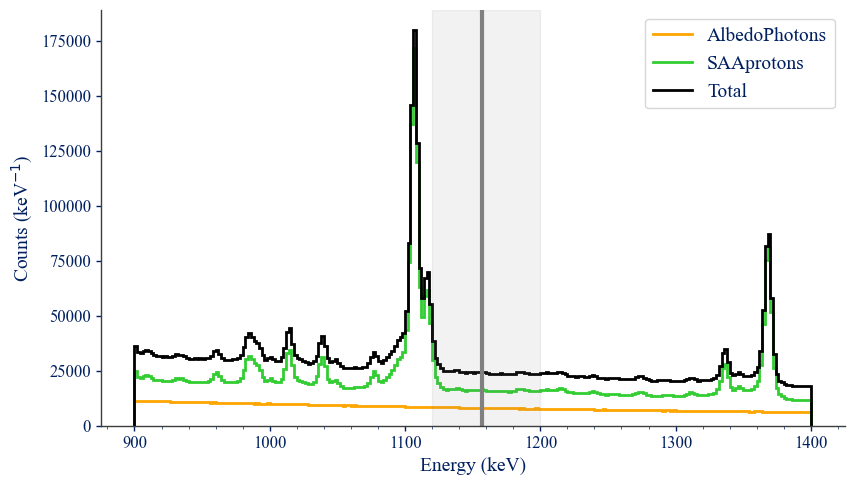

In [6]:
bins = np.linspace(900, 1400, 251)
total = np.zeros(len(bins) - 1)
for key, component in this_dict.items():
    counts, _ = np.histogram(component['Energies'], bins = bins)      # ADC resolution = 0.15 keV
    plt.stairs(counts/np.diff(bins), bins, label=key, lw=2)
    total += counts

plt.stairs(total/np.diff(bins), bins, label='Total', lw=2, color='k')
plt.axvline(1157, c='gray')
plt.axvspan(1120, 1200, color='gray', alpha=0.1)

plt.minorticks_on()
plt.tick_params(axis='y', which='minor', left=False)
plt.xlabel('Energy (keV)')
plt.ylabel('Counts (keV$^{-1}$)')
plt.legend(fontsize=14)
plt.show()

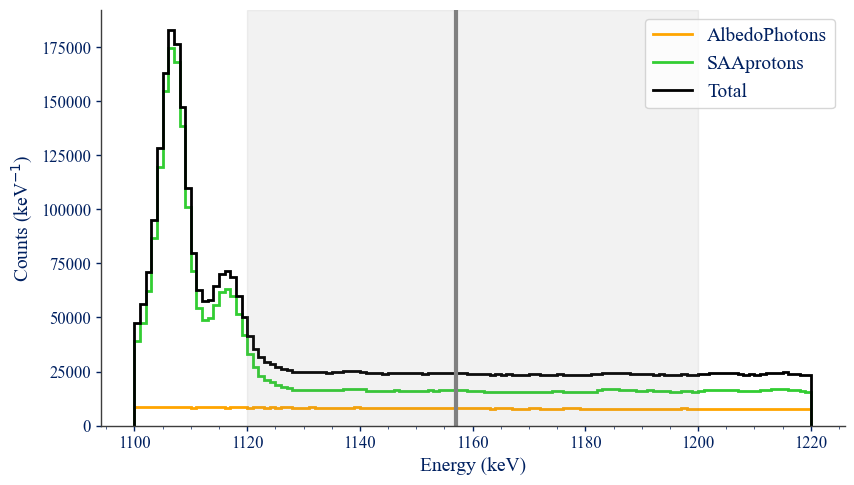

In [37]:
bins = np.linspace(1100, 1220, 121)
total = np.zeros(len(bins) - 1)
for key, component in this_dict.items():
    counts, _ = np.histogram(component['Energies'], bins = bins)      # ADC resolution = 0.15 keV
    plt.stairs(counts/np.diff(bins), bins, label=key, lw=2)
    total += counts

plt.stairs(total/np.diff(bins), bins, label='Total', lw=2, color='k')
plt.axvline(1157, c='gray')
plt.axvspan(1120, 1200, color='gray', alpha=0.1)

plt.minorticks_on()
plt.tick_params(axis='y', which='minor', left=False)
plt.xlabel('Energy (keV)')
plt.ylabel('Counts (keV$^{-1}$)')
plt.legend(fontsize=14)
plt.show()

In [13]:
np.where((component['Energies'] < 1220) & (component['TimeTags'] > 1100))

(array([       0,        2,        3, ..., 43498993, 43498994, 43498995]),)

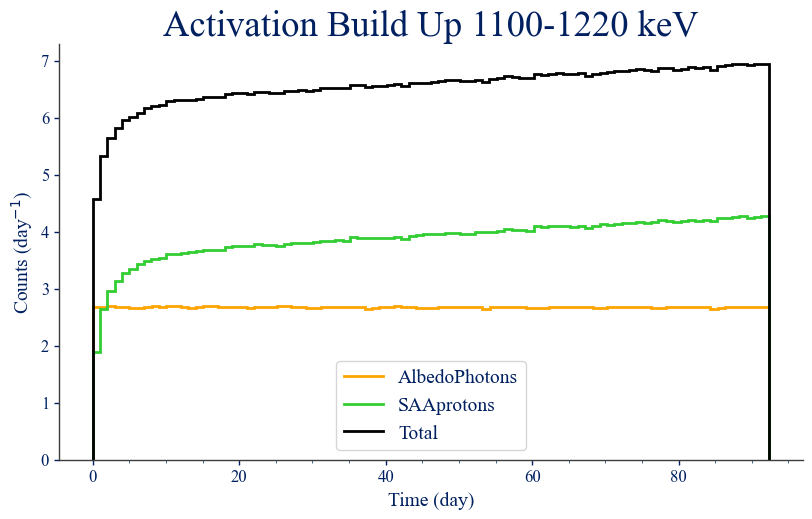

In [15]:
nbins = 92
total = np.zeros(nbins)
for key, component in this_dict.items():
    ydata = component['TimeTags'][np.where((component['Energies'] < 1220) & (component['TimeTags'] > 1100))[0]]
    counts, bins = np.histogram(ydata, bins = nbins)
    plt.stairs(counts/np.diff(bins), (bins-bins[0])/(86400), label=key, lw=2)
    total += counts

plt.stairs(total/np.diff(bins), (bins-bins[0])/(86400), label='Total', lw=2, color='k')

plt.minorticks_on()
plt.tick_params(axis='y', which='minor', left=False)
plt.xlabel('Time (day)')
plt.ylabel('Counts (day$^{-1}$)')
plt.legend(fontsize=14)
plt.title('Activation Build Up 1100-1220 keV')
plt.show()

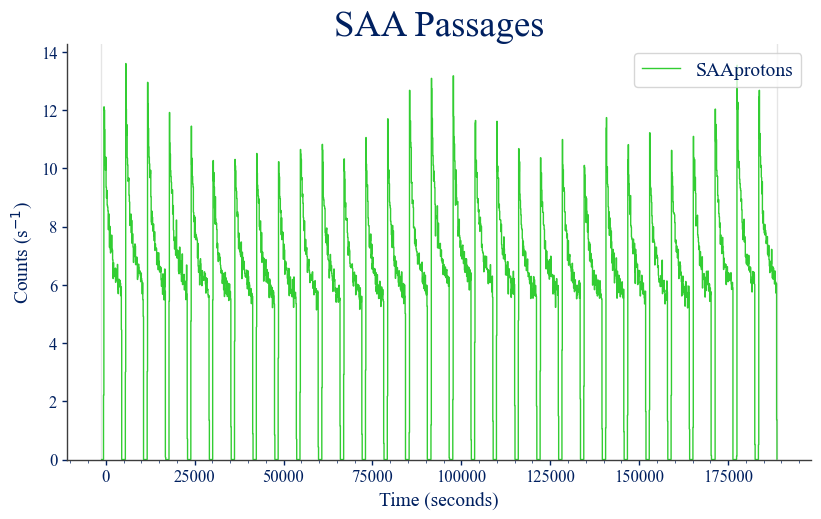

In [6]:
ydata = this_dict['SAAprotons']['TimeTags']
t0 = ydata.min()
t1 = ydata.max()
tstart = t1 - 86400*10

orbital_period = 6138.54        # seconds (from np.fft)
offset = -1340                     # seconds (from visual inspection of the last green bin against grey axvline)
num_passages = 30

time = offset + np.arange(orbital_period*0, orbital_period*(num_passages+1), orbital_period/60)       # In seconds. To stack 6 slices per orbit, need to combine 10 consecutive time bins and fold (i.e., stack)

counts, _ = np.histogram(ydata, bins = tstart + time)
plt.stairs(counts/np.diff(time), time, label='SAAprotons', lw=1, color='limegreen')
plt.axvline(time[0], c='gray', alpha=0.2, lw=1)
plt.axvline(time[-1], c='gray', alpha=0.2, lw=1)
    
plt.minorticks_on()
plt.tick_params(axis='y', which='minor', left=False)
plt.xlabel('Time (seconds)')
plt.ylabel('Counts (s$^{-1}$)')
plt.legend(fontsize=14)

plt.title('SAA Passages')
plt.show()

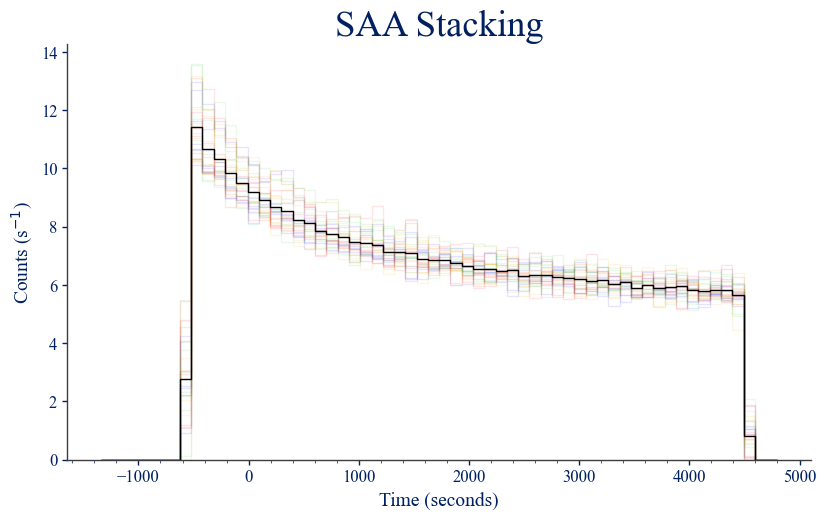

In [358]:
total = np.zeros(int(len(time)/(num_passages+1)))
width = len(total)

for i in range(num_passages):
    idx = i*width
    plt.stairs((counts/np.diff(time))[idx: idx+width], time[:width+1], lw=1, alpha=0.1)
    total += (counts/np.diff(time))[idx: idx+width]
    
plt.stairs(total/num_passages, time[:width+1], lw=1, color='k')

plt.minorticks_on()
plt.tick_params(axis='y', which='minor', left=False)
plt.xlabel('Time (seconds)')
plt.ylabel('Counts (s$^{-1}$)')

plt.title('SAA Stacking')
plt.show()

##### np.fft

In [155]:
ydata = this_dict['SAAprotons']['TimeTags']
t0 = ydata.min()
t1 = ydata.max()

# Example: time and flux data
time = np.arange(t1 - 86400*40, t1, 10)
flux, _ = np.histogram(ydata, bins = time)

# Compute FFT
fft_values = np.fft.fft(flux)
frequencies = np.fft.fftfreq(len(time), d=(time[1] - time[0]))  # Sampling interval

# Ignore zero frequency
nonzero_indices = np.where(frequencies > 0)[0]  # Ensure this is a proper array

# Extract relevant FFT values
fft_magnitudes = np.abs(fft_values[nonzero_indices])  # Filter FFT values properly

# Sort by magnitude
sorted_indices = np.argsort(fft_magnitudes)[::-1]  # Sort correctly

# Get top 5 dominant frequencies
top_frequencies = frequencies[nonzero_indices][sorted_indices[:5]]  # Ensure proper indexing
top_periods = 1 / top_frequencies  # Convert frequencies to periods

print("Top 5 dominant periods:", top_periods)

Top 5 dominant periods: [6138.54351687 3069.27175844 2046.18117229 1534.63587922  767.48834111]


In [323]:
# Constants
G = const.G.value  # m^3/kg/s^2
M = const.M_earth.value  # kg
R_E = const.R_earth.value  # m
T = 6138.54  # seconds

# Compute semi-major axis
a = (G * M * T**2 / (4 * np.pi**2))**(1/3)

# Compute altitude
altitude = a - R_E

print(f"Altitude: {altitude / 1000:.2f} km")

Altitude: 867.97 km


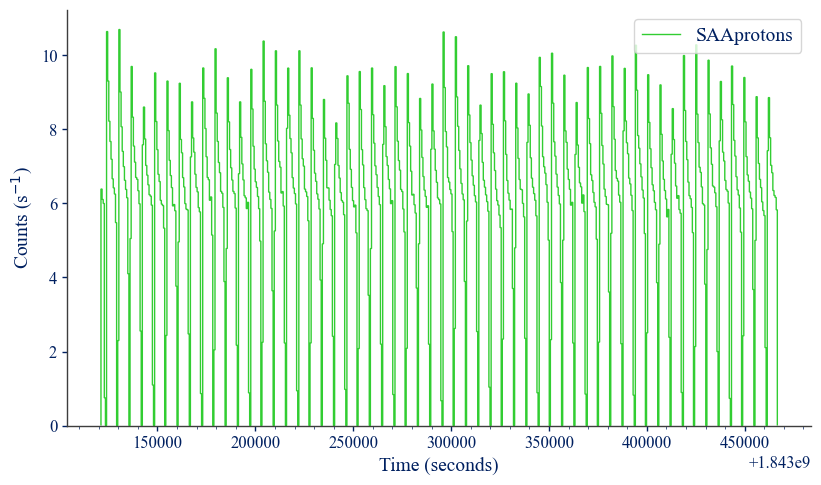

In [ ]:
ydata = this_dict['SAAprotons']['TimeTags']
t0 = ydata.min()
t1 = ydata.max()
bins = np.arange(t1 - 86400*4, t1, 5711.22/10)

counts, _ = np.histogram(ydata, bins = bins)
plt.stairs(counts/np.diff(bins), bins, label='SAAprotons', lw=1, color='limegreen')
    
plt.minorticks_on()
plt.tick_params(axis='y', which='minor', left=False)
plt.xlabel('Time (seconds)')
plt.ylabel('Counts (s$^{-1}$)')
plt.legend(fontsize=14)
plt.show()

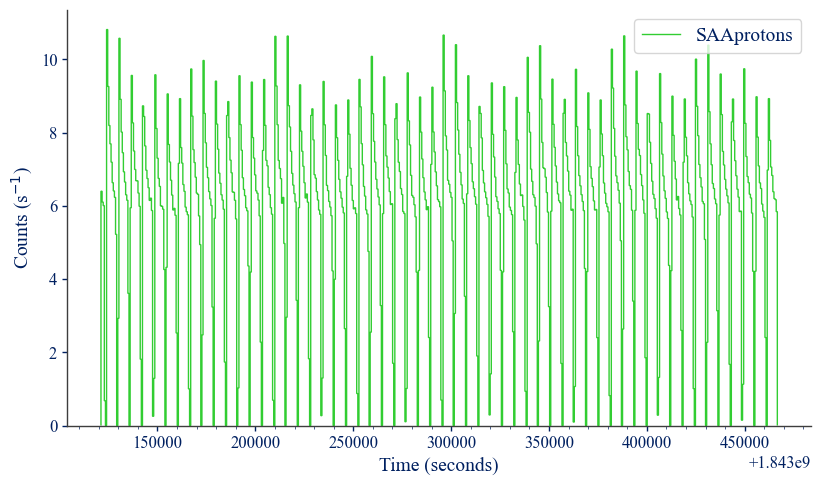

In [ ]:
ydata = this_dict['SAAprotons']['TimeTags']
t0 = ydata.min()
t1 = ydata.max()
bins = np.arange(t1 - 86400*4, t1, 5730/10)

counts, _ = np.histogram(ydata, bins = bins)
plt.stairs(counts/np.diff(bins), bins, label='SAAprotons', lw=1, color='limegreen')
    
plt.minorticks_on()
plt.tick_params(axis='y', which='minor', left=False)
plt.xlabel('Time (seconds)')
plt.ylabel('Counts (s$^{-1}$)')
plt.legend(fontsize=14)
plt.show()

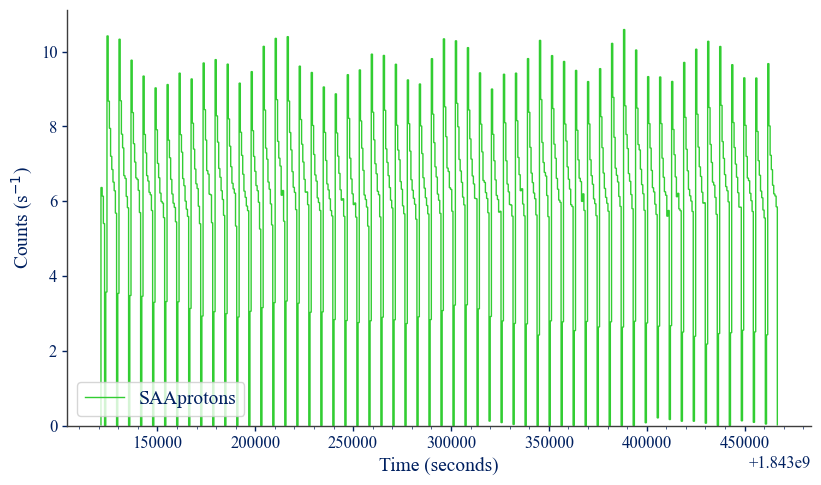

In [ ]:
ydata = this_dict['SAAprotons']['TimeTags']
t0 = ydata.min()
t1 = ydata.max()
bins = np.arange(t1 - 86400*4, t1, 6138.54/10)

counts, _ = np.histogram(ydata, bins = bins)
plt.stairs(counts/np.diff(bins), bins, label='SAAprotons', lw=1, color='limegreen')
    
plt.minorticks_on()
plt.tick_params(axis='y', which='minor', left=False)
plt.xlabel('Time (seconds)')
plt.ylabel('Counts (s$^{-1}$)')
plt.legend(fontsize=14)
plt.show()

#### Binned

In [17]:
# To extract binned data

bg = BinnedData("inputs.yaml")

In [ ]:
bg.energy_bins

In [ ]:
# # Extraction only needs to be done once
# bg.data_file = str(DATA_DIR / 'data/backgrounds/unbinned/AlbedoPhotons_3months_unbinned_data_filtered_with_SAAcut.fits')
# bg.time_bins = 15       # Set time binning to every 15 seconds
# bg.get_binned_data(unbinned_data = bg.data_file, 
#                          output_name = DATA_DIR / 'data/backgrounds/binned/albedo_photons_15s')

In [ ]:
# WIDE ENERGY BIN
bg.data_file = str(DATA_DIR / 'data/backgrounds/unbinned/AlbedoPhotons_3months_unbinned_data_filtered_with_SAAcut.fits')
bg.time_bins = 86400*93       # Specifies size of time bin to full 3 month width
bg_filename = DATA_DIR / f'data/backgrounds/binned/albedo_photons_{int(bg.energy_bins[0])}-{int(bg.energy_bins[-1])}keV'

if bg_filename.with_suffix('.hdf5').is_file():
    bg.load_binned_data_from_hdf5(bg_filename.with_suffix('.hdf5'))
else:
    bg.get_binned_data(unbinned_data = bg.data_file, output_name = bg_filename)

##### Plots

In [89]:
# # Rebinning (manual)

# counts = analysis.binned_data.project('Time').contents.todense()
# bins = analysis.binned_data.project('Time').axis.edges.value
# bins -= bins[0]

# xdata = bins[::4*1440] / 86400      # Rebin 15s (binned_data) to 1 day
# ydata = counts.reshape(-1, 4*1440).sum(axis=-1)

# plt.scatter(xdata[:-1], ydata)
# plt.xlabel('Time (Days)')
# plt.ylabel('Counts')
# plt.show()

(<Axes: xlabel='Time [s]'>, <ErrorbarContainer object of 3 artists>)

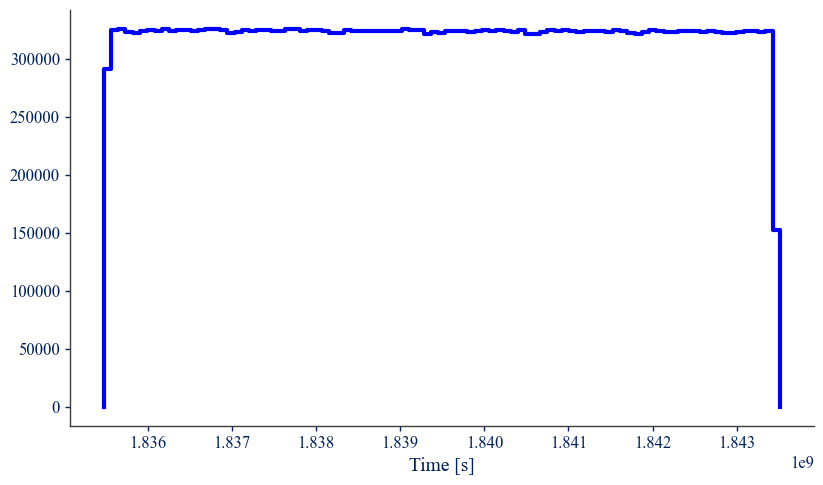

In [ ]:
# Rebinning (Histogram function)

hist = bg.binned_data.project('Time').rebin(4*1440)
hist.plot()
plt.ylabel('Counts')
plt.show()

Background light curve is uniform as expected

In [5]:
bg.binned_data.axes['PsiChi'].__dict__

{'_pix_rangesets': None,
 '_pix_rangesets_argsort': None,
 '_uniq': None,
 '_order': 4,
 '_scheme': 'RING',
 '_coordsys': <Galactic Frame>,
 '_npix_ratio_max': 1125899906842624,
 '_unit': None,
 '_edges': array([   0,    1,    2, ..., 3070, 3071, 3072]),
 '_label': 'PsiChi',
 '_scale': 'linear'}

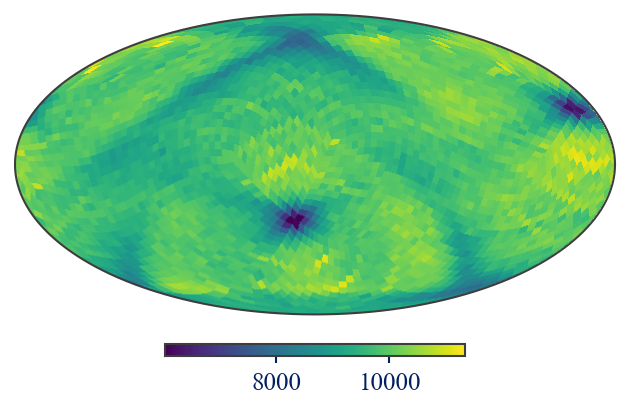

In [ ]:
# Make PsiChi plot
bg.binned_data.project('PsiChi').plot()
plt.xlabel('PsiChi [HEALPix ring pixel number]',fontsize=14)
plt.ylabel('Counts', fontsize=14)
plt.show()

Galactic PsiChi distribution should match the spacecraft exposure map

#### SAA Binned

In [8]:
# To extract binned data

bg_SAA = BinnedData("inputs.yaml")

In [9]:
bg_SAA.energy_bins = np.linspace(1120, 1200, 41)

In [ ]:
# Extraction only needs to be done once
bg_SAA.data_file = str(DATA_DIR / 'data/backgrounds/unbinned/SAA_3months_unbinned_data_filtered_with_SAAcut.fits')
bg_SAA.time_bins = 613.854       # Set time binning to every 613 seconds
bg_SAA_filename = DATA_DIR / f'data/backgrounds/binned/SAA_{int(bg_SAA.energy_bins[0])}-{int(bg_SAA.energy_bins[-1])}keV_{int(bg_SAA.time_bins)}s'

if bg_SAA_filename.with_suffix('.hdf5').is_file():
    bg_SAA.load_binned_data_from_hdf5(bg_SAA_filename.with_suffix('.hdf5'))
else:
    bg_SAA.get_binned_data(unbinned_data = bg_SAA.data_file, output_name = bg_SAA_filename)

# bg_albedo.data_file = str(DATA_DIR / 'data/backgrounds/unbinned/AlbedoPhotons_3months_unbinned_data_filtered_with_SAAcut.fits')

In [11]:
bg_SAA.binned_data.contents.shape

(13090, 40, 60, 3072)

In [12]:
hist = bg_SAA.binned_data.project('Time', 'Em')

(<Axes: xlabel='Time [s]'>, <ErrorbarContainer object of 3 artists>)

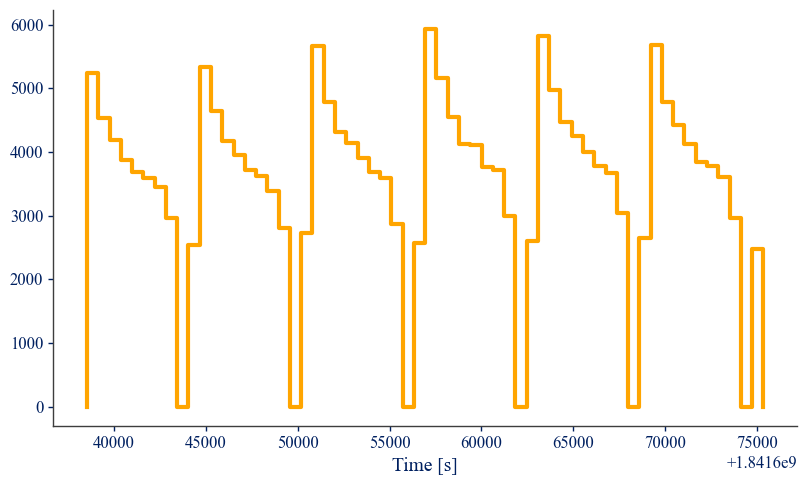

In [39]:
hist.project('Time').slice[10036:10096].plot()

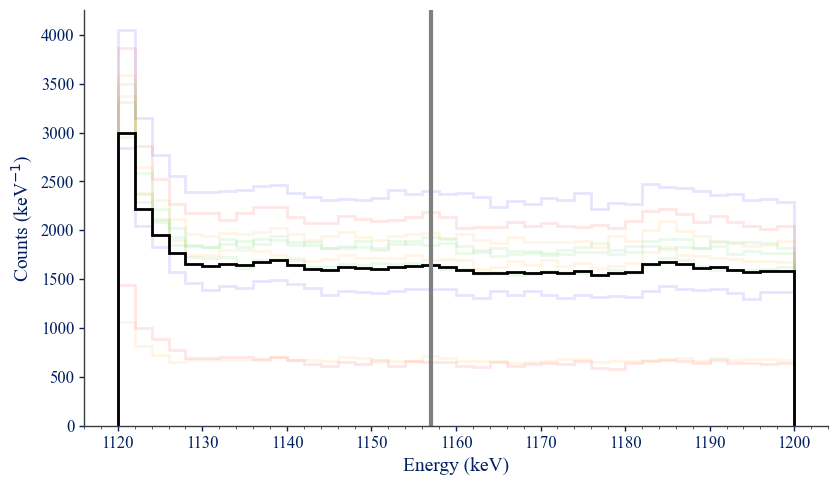

In [91]:
bins = hist.axes['Em'].edges.value

for start_idx in range(10):
    plt.stairs(np.sum(hist[start_idx::10, :].todense(), axis=0) / np.diff(bins), bins, alpha=0.1, lw=2)

plt.stairs(np.sum(hist.todense(), axis=0)/10/np.diff(bins), bins, color='k', lw=2)

plt.axvline(1157, c='gray')

plt.minorticks_on()
plt.tick_params(axis='y', which='minor', left=False)
plt.xlabel('Energy (keV)')
plt.ylabel('Counts (keV$^{-1}$)')
plt.show()

(<Axes: xlabel='Phi [deg]', ylabel='Em [keV]'>,
 <matplotlib.collections.QuadMesh at 0x57f4a9720>)

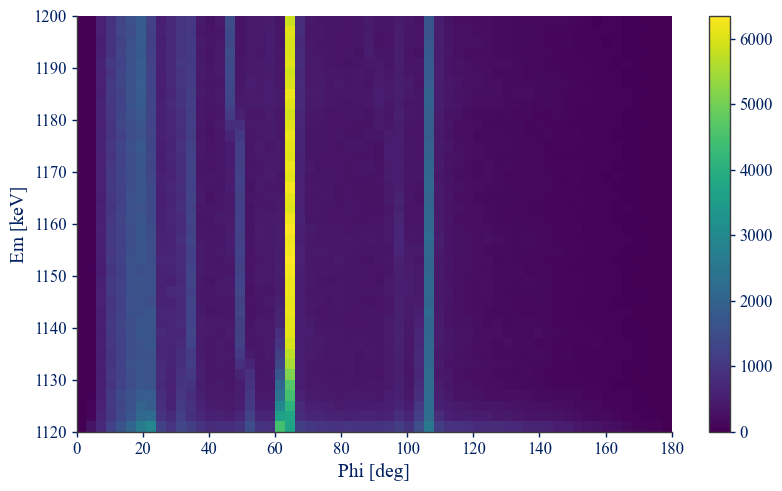

In [159]:
bg_SAA.binned_data.project('Phi', 'Em').plot()

In [139]:
bg_SAA.binned_data.slice[:,:,:,:].axes['PsiChi'].__dict__

{'_pix_rangesets': None,
 '_pix_rangesets_argsort': None,
 '_uniq': None,
 '_order': 4,
 '_scheme': 'RING',
 '_coordsys': <Galactic Frame>,
 '_npix_ratio_max': 1125899906842624,
 '_unit': None,
 '_edges': array([   0,    1,    2, ..., 3070, 3071, 3072]),
 '_label': 'PsiChi',
 '_scale': 'linear'}

In [140]:
bg_SAA.binned_data.axes['PsiChi'].__dict__

{'_pix_rangesets': None,
 '_pix_rangesets_argsort': None,
 '_uniq': None,
 '_order': 4,
 '_scheme': 'RING',
 '_coordsys': <Galactic Frame>,
 '_npix_ratio_max': 1125899906842624,
 '_unit': None,
 '_edges': array([   0,    1,    2, ..., 3070, 3071, 3072]),
 '_label': 'PsiChi',
 '_scale': 'linear'}

In [155]:
np.sum(bg_SAA.binned_data.project('PsiChi'))

43498997.0

In [ ]:
np.sum(bg_SAA.binned_data.slice[:,:,:,:].project('Em'))

1336649.0

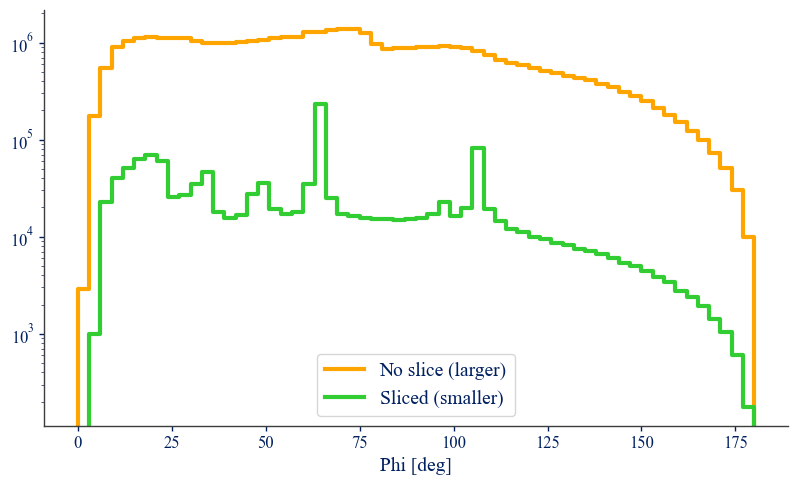

In [157]:
plt.figure()
bg_SAA.binned_data.project('Phi').plot(ax=plt.gca(), label='No slice (larger)')
bg_SAA.binned_data.slice[:,:,:,:].project('Phi').plot(ax=plt.gca(), label='Sliced (smaller)')

plt.yscale('log')
plt.legend(fontsize=14)
plt.show()

(<Mollview: >, <matplotlib.image.AxesImage at 0x5050701f0>)

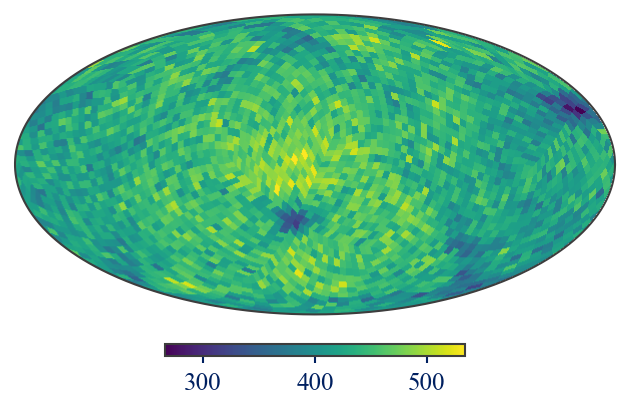

In [130]:
bg_SAA.binned_data.slice[:,:,:,:].project('PsiChi').plot()

### Source

#### Unbinned

In [3]:
# To play with unbinned data

name = 'CasAsymmetric'
source = UnBinnedData("inputs.yaml")
source.data_file = str(DATA_DIR / f'44Ti/sources/{name}_3months_unbinned_data_filtered_with_SAAcut.fits')

In [4]:
this_dict = source.get_dict_from_fits(source.data_file)

In [5]:
source_511 = UnBinnedData("inputs.yaml")
source_511.energy_bins = [500., 522.]
source_511.data_file = str(DATA_DIR / f'511/sources/511_testing_point_source_3months_unbinned_data_filtered_with_SAAcut.fits')

this_dict_511 = source_511.get_dict_from_fits(source_511.data_file)

In [6]:
source_crab = UnBinnedData("inputs.yaml")
source_crab.data_file = str(DATA_DIR / f'Crab/sources/crab_standard_3months_unbinned_data_filtered_with_SAAcut.fits')

this_dict_crab = source_crab.get_dict_from_fits(source.data_file)

##### Fitting with BP23

In [5]:
from lmfit import Model
from lmfit.models import ConstantModel, LinearModel, StepModel
from scipy.special import erf
from matplotlib.offsetbox import AnchoredText

def fwhm_resolution(xprime):
    return 151.442 * xprime**(0.1) / 100

def ExponentialModel_with_center(x, amplitude, Gamma, center):
    return amplitude * np.exp(Gamma * (x-center))

def TailThresholdModel(x, center_t, sigma_t):
    return (1 - erf((x-center_t)/(np.sqrt(2)*sigma_t)))

# Default values set for Cs-137 661.66 keV photopeak
def get_window_spectra_BP23(counts, bincenters, mu=662, Gamma=0.50, CbyB=0.13, D=0.029, sigmatbysigma=0.85):
    model = GaussianModel(prefix='sig_') + ConstantModel(prefix='bg_') + \
            (Model(ExponentialModel_with_center, prefix='exptail_') + LinearModel(prefix='lintail_') + ConstantModel(prefix='consttail_')) * Model(TailThresholdModel, prefix='tailcutoff_', form='erf')
    params = model.make_params()

    # Dummy parameters
    # params._asteval.symtable['CbyB'] = CbyB
    # params._asteval.symtable['D'] = D
    # params._asteval.symtable['sigmatbysigma'] = sigmatbysigma
    params.add('CbyB', value=CbyB, vary=False)
    params.add('D', value=D, vary=False)
    params.add('sigmatbysigma', value=sigmatbysigma, vary=False)
    
    # Gaussian photopeak
    params['sig_amplitude'].set(value=3*np.max(counts), min=0, max=1e6)
    params['sig_center'].set(value=mu, min=mu-5, max=mu+5, vary=True)
    params['sig_sigma'].set(value=fwhm_resolution(mu)/2.355, max=4.5, vary=True)
    
    # Constant background
    params['bg_c'].set(value=np.mean(counts[-10:]), min=0, vary=False)      # bg_c should be the right asymptote
    
    # Exponential component (note that the LMfit definition does not support e^(x-mu). 
    # It only supports e^(-x). Thus, I have multiplied the ExponentialModel with postfactors)
    params['exptail_amplitude'].set(value=1.0, vary=True)      # B in Boggs and Pike 2023
    params['exptail_Gamma'].set(value=Gamma, vary=False)         # Gamma = 0.5 in Boggs and Pike 2023
    params['exptail_center'].set(expr='sig_center')            # E0
    
    # Constant component
    params['consttail_c'].set(expr='CbyB * exptail_amplitude')      # C in Boggs and Pike 2023
    
    # Linear component
    params['lintail_slope'].set(expr='D * consttail_c')         # slope = C*D in Boggs and Pike 2023 (equivalent to slope = C*m in Pike et al 2023)
    params['lintail_intercept'].set(expr='-lintail_slope * sig_center')   # intercept = -1 * slope * mu
    
    # Tail thresholding component
    params['tailcutoff_center_t'].set(expr='sig_center')      # E0
    params['tailcutoff_sigma_t'].set(expr='sigmatbysigma * sig_sigma', min=0)
    
    result = model.fit(counts, params, x=bincenters, scale_covar=False, 
                    #    weights=1/np.amax([np.sqrt(counts), np.ones(len(counts))], axis=0)
                       )
    
    return result

def plot_line_BP23(result, pn=None):
    bincenters = result.userkws['x']
    counts = result.data
    comps = result.eval_components(x=bincenters)
    dely = result.eval_uncertainty(sigma=1)
    dely_comps = result.dely_comps

    yval = result.best_fit
    uncertainty = dely
    plt.plot(bincenters, yval, '-', label='Best fit', lw=2, c='teal')
    plt.fill_between(bincenters, yval - 3*uncertainty, yval + 3*uncertainty, alpha=0.2, facecolor='teal')

    yval = comps['sig_']
    uncertainty = dely_comps['sig_']
    plt.plot(bincenters, yval, label=f"Signal {np.sum(yval):.0f} $\\pm$ {np.sum(uncertainty):.0f}", lw=2)
    plt.fill_between(bincenters, yval - 3*uncertainty, yval + 3*uncertainty, alpha=0.2)

    yval = comps['bg_']
    uncertainty = dely_comps['bg_']
    plt.plot(bincenters, yval, label=f"Bg {np.sum(yval):.0f} (no free params)", lw=2)
    plt.fill_between(bincenters, yval - 3*uncertainty, yval + 3*uncertainty, alpha=0.2)

    yval = (comps['exptail_'] + comps['consttail_'] + comps['lintail_']) * comps['tailcutoff_']
    uncertainty = (dely_comps['exptail_'] + dely_comps['consttail_'] + dely_comps['lintail_']) * comps['tailcutoff_'] + \
                    (comps['exptail_'] + comps['consttail_'] + comps['lintail_']) * dely_comps['tailcutoff_']
    plt.plot(bincenters, yval, 
             label=f"Tail {np.sum(yval):.0f} $\\pm$* {np.sum(uncertainty):.0f}", lw=2)
    plt.fill_between(bincenters, yval - 3*uncertainty, yval + 3*uncertainty, alpha=0.2)

    plt.step(bincenters, counts, alpha=0.3, lw=1, c='k')
    plt.plot([], [], c='w')

    plt.plot([], [], c='w')

    if pn is None:
        plt.title('Both strip sides with 3-$\\mathrm{\\sigma}$ uncertainty bands')
    else:
        plt.title(f'BP23: {pn}-side with 3-$\\mathrm{{\\sigma}}$ uncertainty bands')
    
    at = AnchoredText(f"$\\mu$ = {result.values['sig_center']:.2f} $\\pm$ {result.params['sig_center'].stderr:.2f} keV\
                      \nFWHM = {result.values['sig_sigma']*2.355:.2f} $\\pm$ {result.params['sig_sigma'].stderr*2.355:.2f} keV\
                      \n$\\mathrm{{\\chi_r^2}}$ = {result.redchi:.2f}",
                      loc='upper left', prop={'size':14}, frameon=False)
    plt.gca().add_artist(at)

    plt.minorticks_on()
    # plt.yscale('log')
    # plt.ylim(bottom=0.9)
    plt.legend(fontsize=14)
    plt.show()

In [6]:
tiny = 1e-15
s2 = np.sqrt(2)

def expgaussianleft(x, amplitude=1, center=0, sigma=1.0, gamma=1.0):
    gss = -gamma*sigma*sigma
    arg1 = -gamma*(center + gss/2.0 - x)
    arg2 = (center + gss - x)/max(tiny, (s2*sigma))
    return amplitude*(gamma/2) * np.exp(arg1) * (erf(arg2) + 1)

def get_window_spectra_with_step(counts, bincenters, mu, sigmavary=True):
    model = Model(func=expgaussianleft, prefix='sig_') + ConstantModel(prefix='bg_') + StepModel(prefix='step_', form='erf')
    params = model.make_params()

    params['sig_amplitude'].set(value=np.max(counts), min=0, max=1e6)   # A = sig_amplitude / sqrt(2pi) / sigma
    params['sig_center'].set(value=mu, min=mu-1.5, max=mu+1.5, vary=True)
    params['sig_sigma'].set(value=fwhm_resolution(mu)/2.355, max=4.5, vary=sigmavary)
    params['sig_gamma'].set(value=1.0, max=2.0)     # gamma = 1/tau

    params['bg_c'].set(value=np.mean(counts[:10]) - np.mean(counts[-10:]), min=0, vary=False)      # bg_c should be the left asymptote (as step amplitude is negative)
    params['step_amplitude'].set(value=-np.mean(counts[:10]), min=-np.inf, max=0, vary=False)      # Sum of bg_c and step_amplitude should be the right asymptote
    params['step_center'].set(expr='sig_center')    # See Equation 3 in Lonjou 2005
    params['step_sigma'].set(expr='sig_sigma')

    result = model.fit(counts, params, x=bincenters, scale_covar=False, 
                    #    weights=1/np.amax([np.sqrt(counts), np.ones(len(counts))], axis=0)
                       )

    return result

def plot_line_with_step(result, pn=None):
    bincenters = result.userkws['x']
    counts = result.data
    comps = result.eval_components(x=bincenters)
    dely = result.eval_uncertainty(sigma=1)
    dely_comps = result.dely_comps

    yval = result.best_fit
    uncertainty = dely
    plt.plot(bincenters, yval, '-', label='Best fit')
    plt.fill_between(bincenters, yval - 3*uncertainty, yval + 3*uncertainty, alpha=0.1)

    yval = comps['sig_']
    uncertainty = dely_comps['sig_']
    plt.plot(bincenters, yval, label=f"Signal {np.sum(yval):.0f} $\\pm$ {np.sum(dely_comps['sig_']):.0f}")
    plt.fill_between(bincenters, yval - 3*uncertainty, yval + 3*uncertainty, alpha=0.1)

    yval = comps['bg_'] + comps['step_']
    uncertainty = np.sqrt(dely_comps['bg_']**2 + dely_comps['step_']**2)
    plt.plot(bincenters, yval, 
             label=f"Bg {np.sum(yval):.0f} $\\pm$ {np.sum(np.sqrt(dely_comps['bg_']**2 + dely_comps['step_']**2)):.0f}")
    plt.fill_between(bincenters, yval - 3*uncertainty, yval + 3*uncertainty, alpha=0.1)

    plt.step(bincenters, counts, alpha=0.4, lw=1, c='c')
    plt.plot([], [], c='w')

    if pn is None:
        plt.title('Both strip sides with 3-$\\mathrm{\\sigma}$ uncertainty bands')
    else:
        plt.title(f'L05: {pn}-side with 3-$\\mathrm{{\\sigma}}$ uncertainty bands')
    
    at = AnchoredText(f"$\\mathrm{{\\mu}}$ = {result.values['sig_center']:.2f} $\\pm$ {result.params['sig_center'].stderr:.2f} keV\
                      \nFWHM = {result.values['sig_sigma']*2.355:.2f} $\\pm$ {result.params['sig_sigma'].stderr*2.355:.2f} keV\
                      \n$\\mathrm{{\\chi_r}}$² = {result.redchi:.2f}",
                      loc='upper left', prop={'size':14}, frameon=False)
    plt.gca().add_artist(at)

    plt.minorticks_on()
    # plt.yscale('log')
    # plt.ylim(bottom=0.9)
    plt.legend(fontsize=14)
    plt.show()

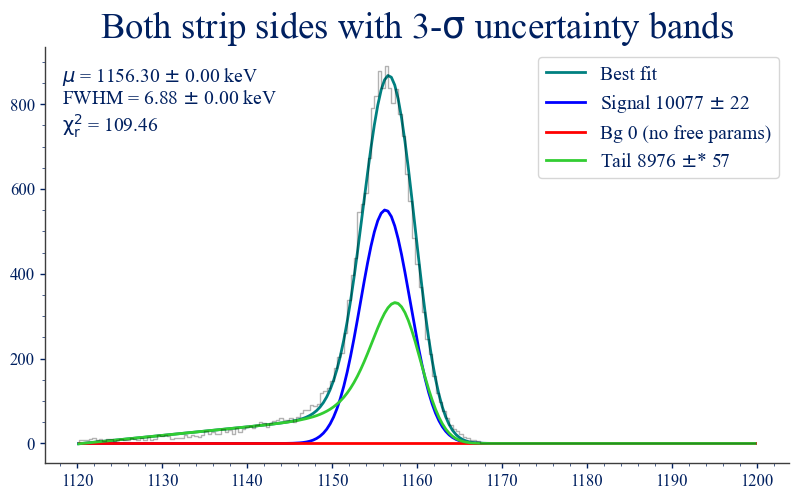

In [14]:
counts, bins = np.histogram(this_dict['Energies'], bins=np.linspace(1120, 1200, 201))

result = get_window_spectra_BP23(counts, (bins[1:]+bins[:-1])/2, 1157,
                                 Gamma=0.49, CbyB=0.13, D=0.028, sigmatbysigma=0.84
                                 )
plot_line_BP23(result)

BP23 fits single-site, photoelectric events; not Compton scattered events. 
Additionally, why is the tail going to negative values.

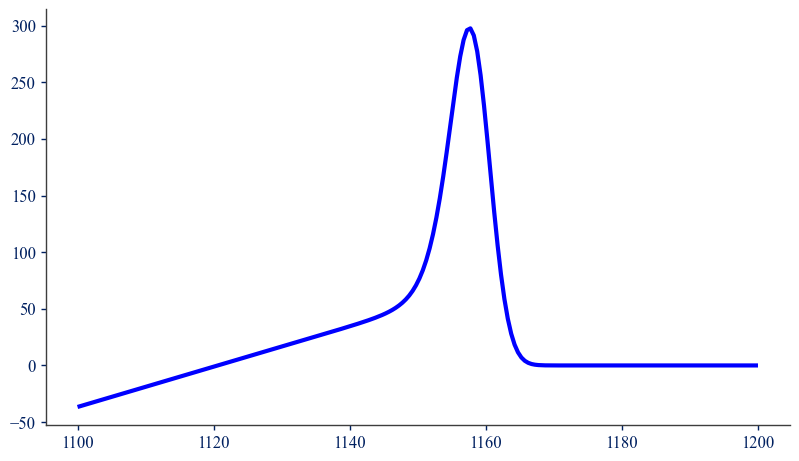

In [ ]:
bincenters = result.userkws['x']
comps = result.eval_components(x=bincenters)
yval = (comps['exptail_'] + comps['consttail_'] + comps['lintail_']) * comps['tailcutoff_']
plt.plot(bincenters, yval)

##### Unbinned Plots

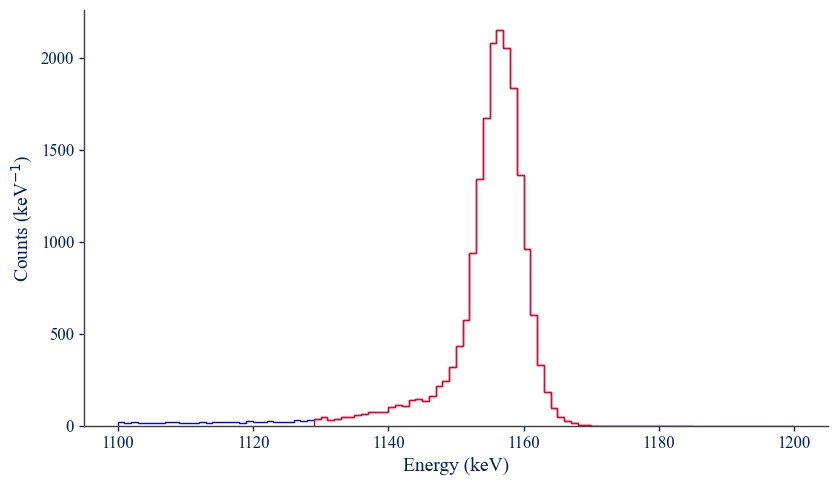

In [ ]:
counts, bins = np.histogram(this_dict['Energies'], bins=np.linspace(1100, 1200, 101))
plt.stairs(counts / np.diff(bins), bins)
counts, bins = np.histogram(this_dict['Energies'], bins=np.linspace(1129, 1185, 57))
plt.stairs(counts / np.diff(bins), bins)
plt.ylabel('Counts (keV$^{-1}$)')
plt.xlabel('Energy (keV)')
plt.savefig()
plt.show()  

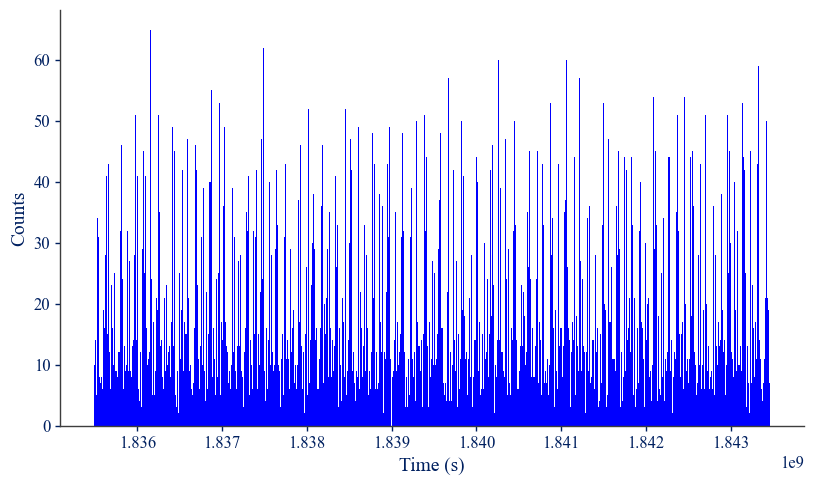

In [6]:
plt.hist(this_dict['TimeTags'], bins=93*24+1)
plt.xlabel('Time (s)')
plt.ylabel('Counts')
plt.show()

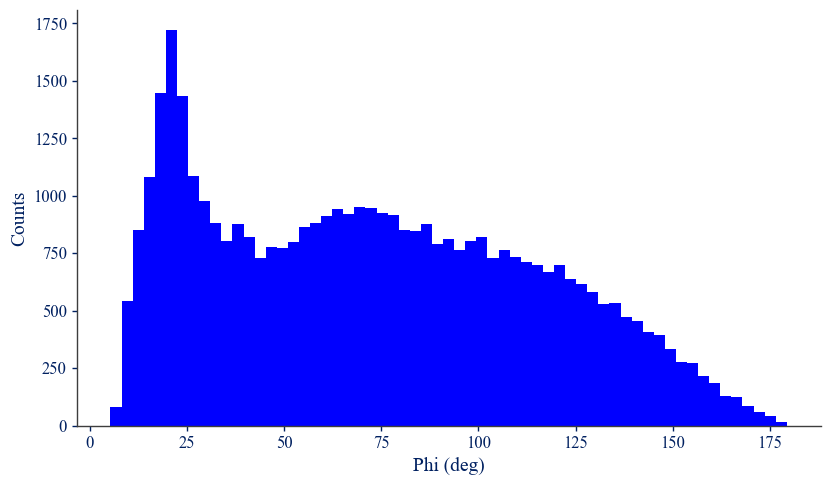

In [14]:
counts, bins = np.histogram(np.rad2deg(this_dict['Phi']), bins=61)
plt.stairs(counts, bins, fill=True)
plt.xlabel('Phi (deg)')
plt.ylabel('Counts')
plt.show()

##### Klein-Nishina Comparison

In [8]:
import astropy.units as u
import astropy.constants as const

m_e = const.m_e
c = const.c
e = const.e.si
eps0 = const.eps0
PI = np.pi
r_e = 1 / (4 * PI * eps0) * (e**2 / (m_e * c**2))
r_e = r_e.to(u.fm)

def Compton_scattering_energy(Ein, phi):
    a = Ein / (m_e * c**2) * (1 - np.cos(phi))
    b = 1 + a   # denominator
    Eout = Ein / b
    return Eout

def Compton_scattering_cross_section(Ein, phi, Eout):
    a = 1/2 * r_e**2 * (Eout/Ein)**2
    b = Ein/Eout + Eout/Ein - np.sin(phi)**2
    return a*b

def Compton_PDF(Ein, phi):
    Eout = Compton_scattering_energy(Ein, phi)
    cross_section = Compton_scattering_cross_section(Ein, phi, Eout)
    pdf = (cross_section[:-1] + cross_section[1:]) / 2 / cross_section.sum() / np.diff(-phi)
    return pdf

cosphi = np.linspace(-1, 1, 1001)
phi = np.arccos(cosphi)

pdf = Compton_PDF(Ein = 1157 * u.keV, phi = phi)

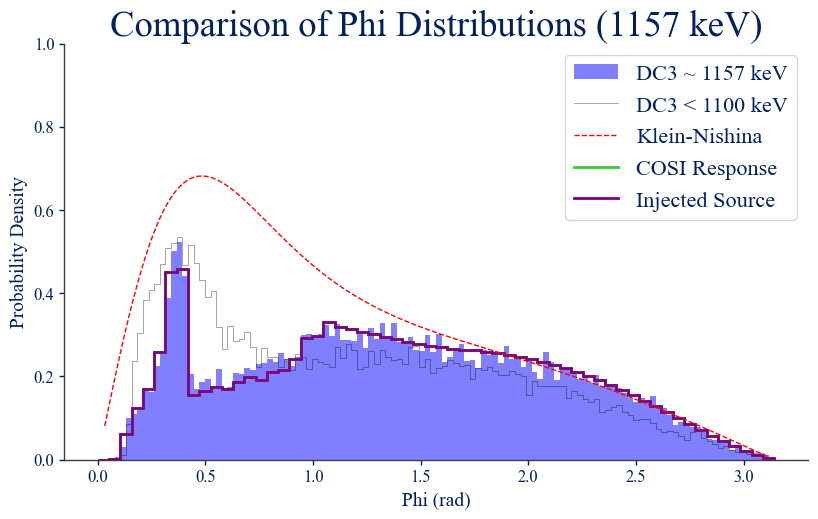

37.5% probability of rejecting an event because of its scatter angle


In [ ]:
idx = np.where((1129 < this_dict['Energies']) & (this_dict['Energies'] < 1185))[0]
counts, bins = np.histogram(this_dict['Phi'][idx], bins = np.deg2rad(np.linspace(0, 180, 121)))
plt.stairs(counts / np.diff(bins) / counts.sum() / 1.6, bins, fill=True, alpha=0.5, label='DC3 ~ 1157 keV')

# idx = np.where((1160 < this_dict['Energies']) & (this_dict['Energies'] < 1185))[0]
# counts, bins = np.histogram(this_dict['Phi'][idx], bins = np.deg2rad(np.linspace(0, 180, 61)))
# plt.stairs(counts / np.diff(bins) / counts.sum() / 1.6, bins, lw=2)

idx = np.where(this_dict['Energies'] < 1100)[0]
counts, bins = np.histogram(this_dict['Phi'][idx], bins = np.deg2rad(np.linspace(0, 180, 121)))
plt.stairs(counts / np.diff(bins) / counts.sum() / 1.6, bins, lw=0.5, alpha=0.5, color='k', label = 'DC3 < 1100 keV')

plt.plot((phi[:-1] + phi[1:])/2, pdf, ls='--', lw=1, label='Klein-Nishina')
plt.stairs(ydata / ydata.sum() / np.diff(np.deg2rad(xdata)) / 1.6, np.deg2rad(xdata.value), lw=2, label='COSI Response')      # Run psr_SAA cell before this
plt.stairs(ydata2 / ydata2.sum() / np.diff(np.deg2rad(xdata2)) / 1.6, np.deg2rad(xdata2.value), lw=2, color='purple', label='Injected Source')      # Run injected source binned data cell before this

plt.xlabel('Phi (rad)')
plt.ylabel('Probability Density')
plt.title('Comparison of Phi Distributions (1157 keV)')
plt.ylim([0, 1])
plt.legend(fontsize=16)
plt.show()

print(f'{np.round(1-1/1.6, 3)*100}% probability of rejecting an event because of its scatter angle')

In [285]:
np.rad2deg([0.5, 1, 1.5])

array([28.64788976, 57.29577951, 85.94366927])

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.00017794533460207038
        x: [ 1.611e+00]
      nit: 8
      jac: [-2.825e-06]
 hess_inv: [[ 6.776e+01]]
     nfev: 18
     njev: 9

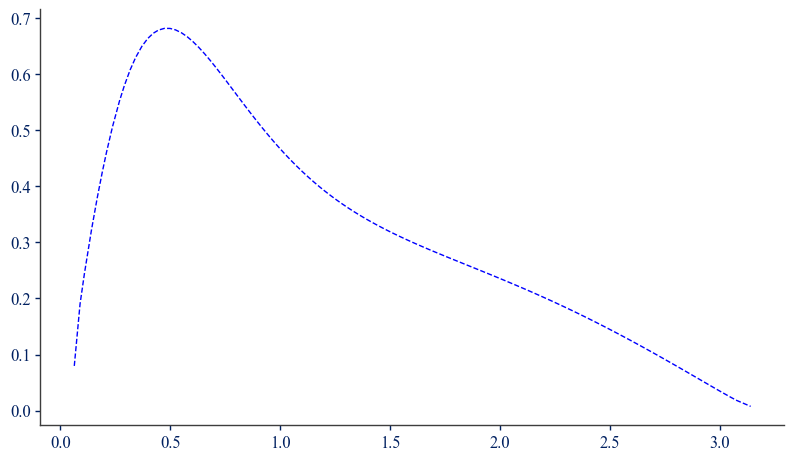

In [ ]:
# idx = [np.argmin(np.abs((phi[:-1] + phi[1:])/2 - b)) for b in bins]
# plt.plot(phi[idx], pdf[idx], lw=1, ls='--')
# f = lambda a: np.mean((pdf[idx][50:-1] - (counts / np.diff(bins) / counts.sum())[50:] / a)**2)
# minimize(f, 1)

#### Binned

In [5]:
# To extract binned data
src = BinnedData("inputs.yaml")
name = 'CasAFullyResolved'

In [4]:
# # Extraction only needs to be done once
# name = 'CasAfullyresolved'
# src.data_file = str(DATA_DIR / f'44Ti/sources/{name}_3months_unbinned_data_filtered_with_SAAcut.fits')
# src.time_bins = 15       # Set time binning to every 15 seconds
# src.get_binned_data(unbinned_data = src.data_file, 
#                          output_name = DATA_DIR / f'44Ti/sources/{name}_15s')

In [7]:
# WIDE ENERGY BIN
src.data_file = str(DATA_DIR / f'44Ti/sources/{name}_3months_unbinned_data_filtered_with_SAAcut.fits')
src.time_bins = 86400*93       # Specifies size of time bin to full 3 month width
src_filename = DATA_DIR / f'44Ti/sources/{name}_{int(src.energy_bins[0])}-{int(src.energy_bins[-1])}keV'

if src_filename.with_suffix('.hdf5').is_file():
    src.load_binned_data_from_hdf5(src_filename.with_suffix('.hdf5'))
else:
    src.get_binned_data(unbinned_data = src.data_file, output_name = src_filename)

In [ ]:
# src_inj = BinnedData("inputs.yaml")
# src_inj.load_binned_data_from_hdf5(DATA_DIR / f'44Ti/sources/CasA_injected.h5')

# ydata2 = src_inj.binned_data.project('Phi').contents
# xdata2 = src_inj.binned_data.axes['Phi'].edges

This source data is in data space.

In [6]:
src.binned_data.axes.labels, src.binned_data.contents.shape

(array(['Time', 'Em', 'Phi', 'PsiChi'], dtype='<U6'), (1, 1, 60, 3072))

##### Binned vs Unbinned plots

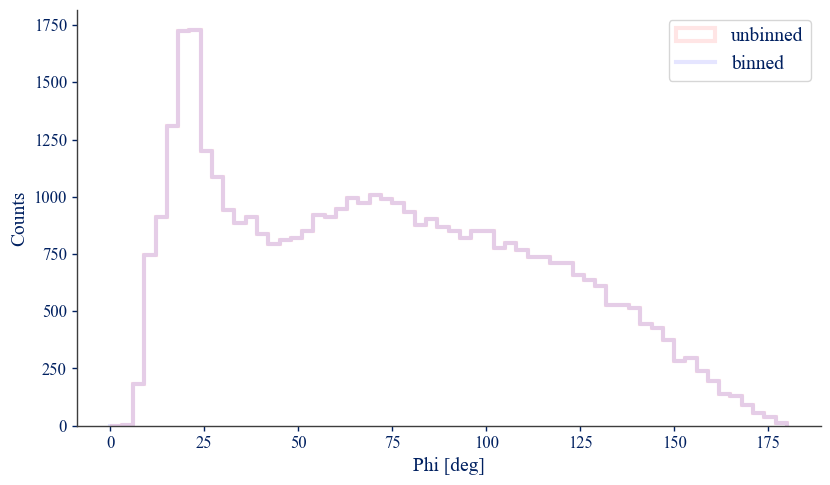

In [ ]:
ax, _ = src.binned_data.project('Phi').todense().plot(label='binned', alpha=0.1)
ax.hist(np.rad2deg(this_dict['Phi']), bins=np.linspace(0,180,61), histtype='step', label='unbinned', lw=3, alpha=0.1)
plt.ylabel('Counts')
plt.legend(fontsize=14)
plt.show()

In [60]:
src.binned_data.project('Em').todense().contents

array([11154.])

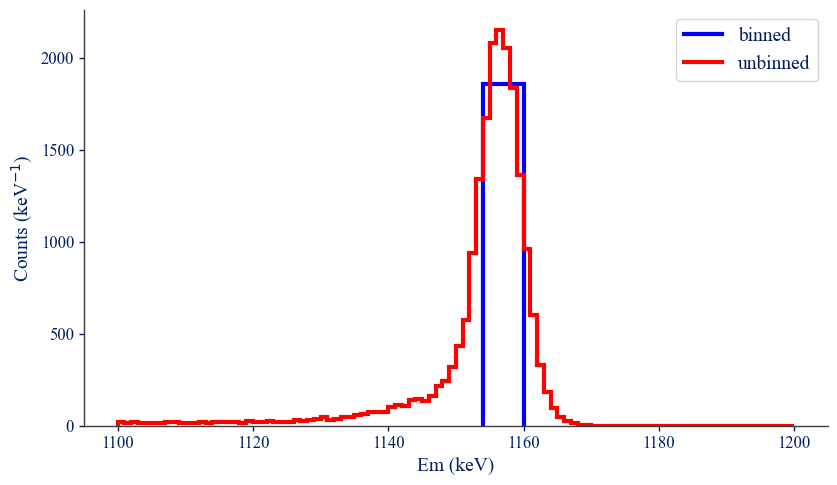

In [ ]:
counts = src.binned_data.project('Em').todense().contents
bins = src.binned_data.axes['Em'].edges.value
plt.stairs(counts/np.diff(bins), bins, lw=3, label='binned')

counts, bins = np.histogram(this_dict['Energies'], bins=np.linspace(1100, 1200, 101))
plt.stairs(counts/np.diff(bins), bins, label='unbinned', lw=3)

plt.xlabel('Em (keV)')
plt.ylabel('Counts (keV$^{-1}$)')
plt.legend(fontsize=14)
plt.show()

### Response

In [3]:
response_filename = DATA_DIR / 'data/responses/Response44Ti.o4.e1154_1160.s9607532021290.m1215.filtered.nonsparse.binnedimaging.imagingresponse_nside16.area.h5'

In [ ]:
with FullDetectorResponse.open(response_filename) as response:
    print(response.filename)

/Users/penguin/Documents/Grad School/Research/COSI/COSIpy/docs/DC3/data/responses/Response44Ti.o4.e1154_1160.s9607532021290.m1215.filtered.nonsparse.binnedimaging.imagingresponse_nside16.area.h5


In [ ]:
with FullDetectorResponse.open(response_filename) as response:
    print(repr(response))

FILENAME: '/Users/penguin/Documents/Grad School/Research/COSI/COSIpy/docs/DC3/data/responses/Response44Ti.o4.e1154_1160.s9607532021290.m1215.filtered.nonsparse.binnedimaging.imagingresponse_nside16.area.h5'
AXES:
  NuLambda:
    DESCRIPTION: 'Location of the simulated source in the spacecraft coordinates'
    TYPE: 'healpix'
    NPIX: 3072
    NSIDE: 16
    SCHEME: 'RING'
  Ei:
    DESCRIPTION: 'Initial simulated energy'
    TYPE: 'log'
    UNIT: 'keV'
    NBINS: 1
    EDGES: [1154.0 keV, 1160.0 keV]
  Em:
    DESCRIPTION: 'Measured energy'
    TYPE: 'log'
    UNIT: 'keV'
    NBINS: 1
    EDGES: [1154.0 keV, 1160.0 keV]
  Phi:
    DESCRIPTION: 'Compton angle'
    TYPE: 'linear'
    UNIT: 'deg'
    NBINS: 60
    EDGES: [0.0 deg, 3.0 deg, 6.0 deg, 9.0 deg, 12.0 deg, 15.0 deg, 18.0 deg, 21.0 deg, 24.0 deg, 27.0 deg, 30.0 deg, 33.0 deg, 36.0 deg, 39.0 deg, 42.0 deg, 45.0 deg, 48.0 deg, 51.0 deg, 54.0 deg, 57.0 deg, 60.0 deg, 63.0 deg, 66.0 deg, 69.0 deg, 72.0 deg, 75.0 deg, 78.0 deg, 81.0 

In [20]:
with FullDetectorResponse.open(response_filename) as response:
    dr = response[1300]

### Spacecraft Attitude and Orientation

#### Ori DC2 Format

In [6]:
ori_path = DATA_DIR / 'data/orientation/DC3_final_530km_3_month_with_slew_15sbins_GalacticEarth.ori'
response_path = DATA_DIR / 'data/responses/Response44Ti.o4.e1154_1160.s9607532021290.m1215.filtered.nonsparse.binnedimaging.imagingresponse_nside16.area.h5'

In [ ]:
# define the target coordinates (Cas A)
target_coord = SkyCoord.from_name('Cas A').galactic

In [8]:
# read the full oritation
ori = SpacecraftFile.parse_from_file(ori_path)

ValueError: invalid column index 9 at row 1 with 9 columns

#### Ori Local

In [ ]:
# ori_local = SpacecraftFile.parse_from_file(ori_path.parent / 'DC3_final_530km_3_month_with_slew_15sbins_EarthLocal.ori')

In [ ]:
# for key in ori_local.__dict__:
#     print(ori.__dict__[key] == ori_local.__dict__[key])

[ True  True  True ...  True  True  True]
[ True  True  True ...  True  True  True]
True
[ True  True  True ...  True  True  True]
False
[ True  True  True ...  True  True  True]
[[ True  True]
 [ True  True]
 [ True  True]
 ...
 [ True  True]
 [ True  True]
 [ True  True]]
[[ True  True]
 [ True  True]
 [ True  True]
 ...
 [ True  True]
 [ True  True]
 [ True  True]]
True


In [ ]:
# for key in ori.__dict__:
#     if key not in ori_local.__dict__:
#         print('new', key)
#     else:
#         print(key)

_time
x_pointings
y_pointings
z_pointings
attitude
_load_time
_x_direction
_z_direction
frame
new target_name
new src_path_cartesian
new src_path_spherical
new src_path_lb
new src_path_skycoord
new response_file
new _time_delta
new dts
new dwell_map


In [ ]:
# for key in ori_local.__dict__:
#     if key not in ['y_pointings', 'attitude', 'dwell_map']:
#         print(all(ori.__dict__[key] == ori_local.__dict__[key]))

True
True
True
True


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

#### Exposure / dwell time Map

In [12]:
# get the target movement in the reference frame attached to the detector
target_in_sc_frame = ori.get_target_in_sc_frame(target_name = 'Cas A', target_coord = target_coord)

# Get the dwell time map
dwell_time_map = ori.get_dwell_map(response = response_path, src_path = target_in_sc_frame)

In [13]:
with FullDetectorResponse.open(response_path) as response:
    psr_exp = response.get_point_source_response(exposure_map = dwell_time_map, coord = target_coord)

In [ ]:
F = 1e-5 * u.ph / u.cm / u.cm / u.s
mu = 1157 * u.keV
sigma = 5 * u.keV

spectrum = Gaussian()
spectrum.F.value = F.value
spectrum.F.unit = F.unit
spectrum.mu.value = mu.value 
spectrum.mu.unit = mu.unit
spectrum.sigma.value = sigma.value
spectrum.sigma.unit = sigma.unit

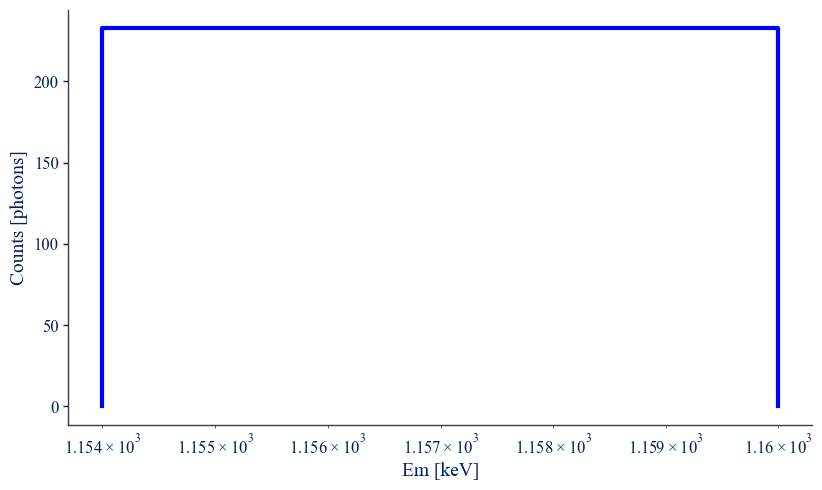

In [18]:
expectation = psr_exp.get_expectation(spectrum)

expectation.project('Em').plot()
plt.ylabel('Counts [photons]')
plt.show()

#### ScAtt Map

In [19]:
scatt_map = ori.get_scatt_map(nside = 16, coordsys = 'galactic')

NameError: name 'ori' is not defined

In [ ]:
# # Only needs to be created once
# with FullDetectorResponse.open(response_path) as response:
#     psr_scatt = response.get_point_source_response(coord = target_coord, scatt_map = scatt_map)

# psr_scatt.write('psr_scatt_hist.h5')

In [20]:
hist = Histogram.open('psr_scatt_hist.h5')

# # TODO: Need functionality to load PSR from .h5 file
# psr_scatt = PointSourceResponse(hist.axes,
#                                 contents=hist.contents,
#                                 sparse=hist._sparse,
#                                 unit=hist.unit)

In [52]:
new_axes = []

for axis in hist.axes[:2]:
    new_axes += [Axis(np.array(src.energy_bins) * u.keV,
                    label = axis.label,
                    scale = axis.axis_scale)]

axis = hist.axes[2]
new_axes += [Axis(axis.edges, label = axis.label,
                  scale = axis.axis_scale)]

axis = hist.axes[3]
new_axes += [HealpixAxis(edges=np.array(axis),
                         nside=axis.nside,
                         label=axis.label,
                         scheme=axis.scheme,
                         coordsys=axis.coordsys)]

NameError: name 'hist' is not defined

In [22]:
psr_scatt = PointSourceResponse(new_axes,
                                contents=hist.contents,
                                sparse=hist._sparse,
                                unit=hist.unit)

In [23]:
psr_scatt.axes['Em'].edges

<Quantity [1129., 1185.] keV>

In [ ]:
# TODO: How do you increase the width of the Em and Ei bin and accordingly re-normalize the contents?

###### Sanity Check

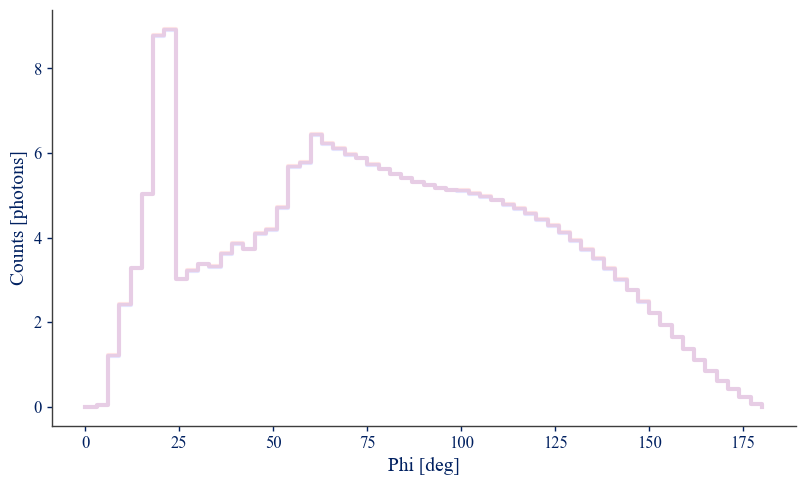

In [39]:
expectation = psr_scatt.get_expectation(spectrum)
ax, plot = expectation.project('Phi').plot(alpha=0.1)

expectation = psr_exp.get_expectation(spectrum)
expectation.project('Phi').plot(ax=ax, alpha=0.1)

plt.ylabel('Counts [photons]')
plt.show()

In [114]:
psr_exp.axes['PsiChi'].coordsys, psr_exp.contents.unit

(<SpacecraftFrame Frame (attitude=None, obstime=None, location=None)>,
 Unit("cm2 s"))

In [113]:
psr_scatt.axes['PsiChi'].coordsys, psr_scatt.contents.unit

(<Galactic Coordinate: (l, b) in deg
     (111.73761886, -2.13450707)>,
 Unit("cm2 s"))

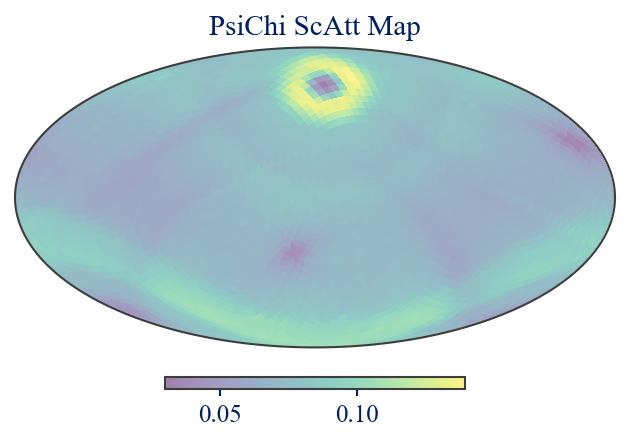

In [101]:
expectation = psr_scatt.get_expectation(spectrum)
ax, plot = expectation.project('PsiChi').plot(alpha=0.5)

# expectation = psr_exp.get_expectation(spectrum)
# expectation.project('PsiChi').plot(ax=ax, alpha=0.5)

ax.set_title('PsiChi ScAtt Map', fontsize=14)
plt.show()

In [165]:
psr_scatt.contents.shape

(1, 1, 60, 3072)

##### ScAtt Map Local

In [ ]:
scatt_map_local = ori_local.get_scatt_map(nside = 16, coordsys = 'galactic')

In [ ]:
with FullDetectorResponse.open(response_path) as response:
    psr_scatt_local = response.get_point_source_response(coord = target_coord, scatt_map = scatt_map_local)

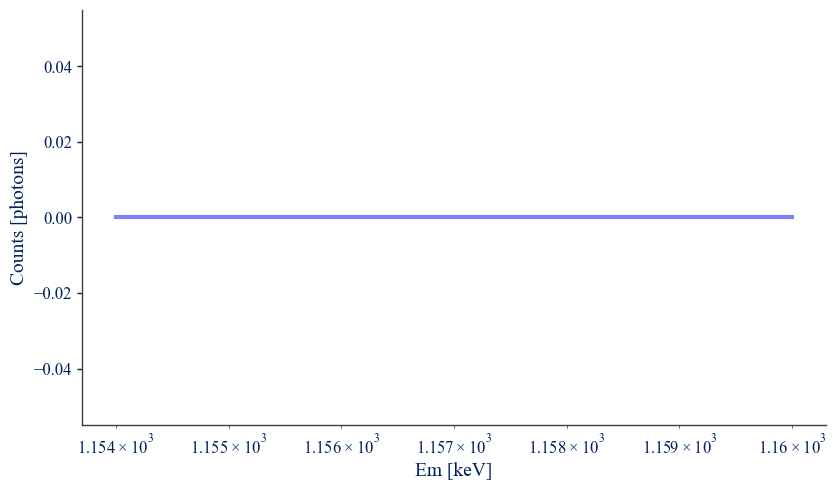

In [ ]:
expectation = psr_scatt_local.get_expectation(spectrum) - psr_scatt.get_expectation(spectrum)

expectation.project('Em').plot(alpha=0.5)
plt.ylabel('Counts [photons]')
plt.show()

#### ScAtt Map with SAA Cut

In [8]:
# define the target coordinates (Cas A)
target_coord = SkyCoord.from_name('Cas A').galactic

In [9]:
ori_path = DATA_DIR / 'data/orientation/DC3_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.ori'
response_path = DATA_DIR / 'data/responses/Response44Ti.o4.e1154_1160.s9607532021290.m1215.filtered.nonsparse.binnedimaging.imagingresponse_nside16.area.h5'
ori_SAA = SpacecraftFile.parse_from_file(ori_path)

In [ ]:
# ori_SAA.__dict__.keys(), ori.__dict__.keys()

(dict_keys(['_time', '_altitude', 'livetime', 'x_pointings', 'y_pointings', 'z_pointings', 'earth_zenith', 'attitude', '_load_time', '_x_direction', '_z_direction', '_earth_direction', 'frame']),
 dict_keys(['_time', '_altitude', 'livetime', 'x_pointings', 'y_pointings', 'z_pointings', 'earth_zenith', 'attitude', '_load_time', '_x_direction', '_z_direction', '_earth_direction', 'frame']))

In [ ]:
scatt_map_SAA = ori_SAA.get_scatt_map(nside = 16, coordsys = 'galactic', target_coord = target_coord)

In [ ]:
# # Only needs to be created once
# with FullDetectorResponse.open(response_path) as response:
#     psr_SAA = response.get_point_source_response(coord = target_coord, scatt_map = scatt_map_SAA)

# psr_SAA.write('psr_scatt_SAA_hist_DC3.h5')

In [11]:
hist_SAA = Histogram.open('psr_scatt_SAA_hist_DC3.h5')

new_axes = []

for axis in hist_SAA.axes[:2]:
    new_axes += [Axis(np.array(src.energy_bins) * u.keV,
                    label = axis.label,
                    scale = axis.axis_scale)]

axis = hist_SAA.axes[2]
new_axes += [Axis(axis.edges, label = axis.label,
                  scale = axis.axis_scale)]

axis = hist_SAA.axes[3]
new_axes += [HealpixAxis(edges=np.array(axis),
                         nside=axis.nside,
                         label=axis.label,
                         scheme=axis.scheme,
                         coordsys=axis.coordsys)]

In [ ]:
psr_SAA = PointSourceResponse(new_axes,
                              contents=hist_SAA.contents,
                              sparse=hist_SAA._sparse,
                              unit=hist_SAA.unit)

(<Mollview: >, <matplotlib.image.AxesImage at 0x2ab92d540>)

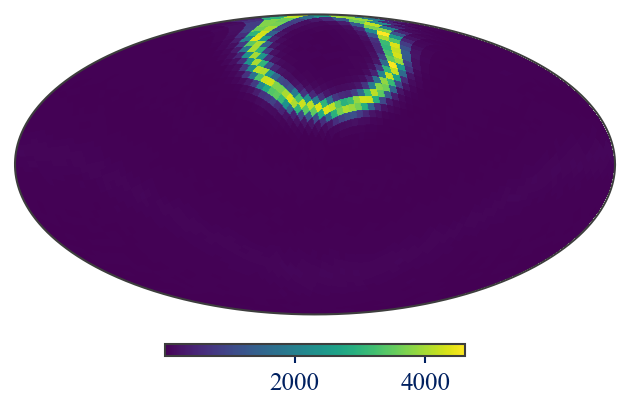

In [85]:
psr_SAA.project('Phi', 'PsiChi').slice[10, :].project('PsiChi').plot()

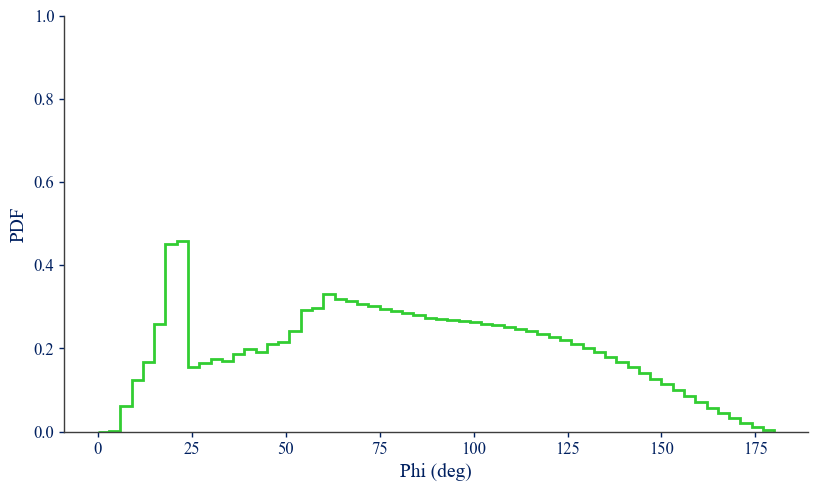

In [15]:
h = psr_SAA.project('Phi')
xdata = h.axes['Phi'].edges
ydata = h.contents

plt.stairs(ydata / ydata.sum() / np.diff(np.deg2rad(xdata)) / 1.6, xdata.value, edgecolor='limegreen', lw=2)        # 1.6 factor from normalization analysis of unbinned source data
plt.xlabel('Phi (deg)')
plt.ylabel('PDF')
plt.ylim([0, 1])
plt.show()

((<Mollview: >, <matplotlib.image.AxesImage at 0x2bb516d10>),)

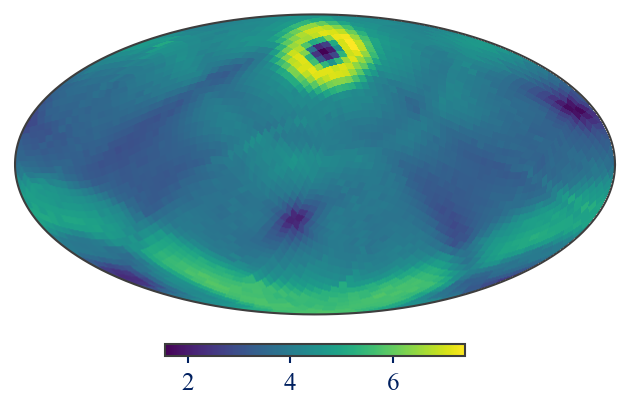

In [144]:
psr_SAA.get_expectation(spectrum).project('PsiChi').plot(), 

(<Mollview: >, <matplotlib.image.AxesImage at 0x2ffd99150>)

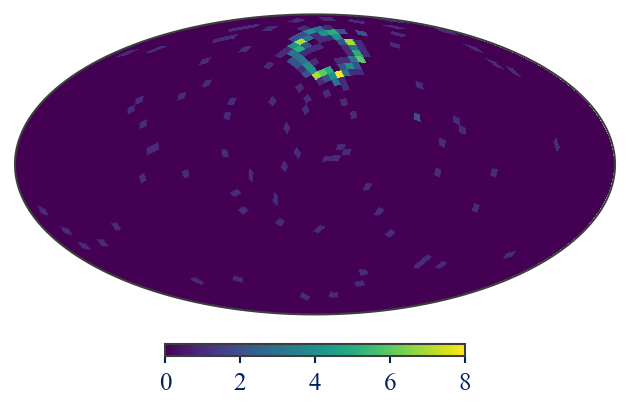

In [145]:
src.binned_data.slice[:, :, 4, :].project('PsiChi').plot()

(<Mollview: >, <matplotlib.image.AxesImage at 0x2ab162410>)

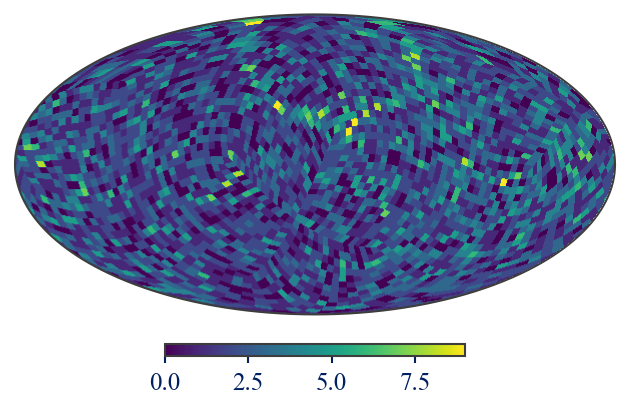

In [146]:
data.slice[:, 12, :].project('PsiChi').plot()

### Spectral Fitting

In [143]:
F = 3e-4 / u.cm / u.cm / u.s
mu = 1157 * u.keV
sigma = 3.85/2.355 * u.keV

spectrum = Gaussian()
spectrum.F.value = F.value
spectrum.F.min_value = F.value / 1e3
spectrum.F.max_value = F.value * 1e3
spectrum.F.unit = F.unit
spectrum.mu.value = mu.value 
spectrum.mu.min_value = mu.value - 10
spectrum.mu.max_value = mu.value + 10
spectrum.mu.unit = mu.unit
spectrum.sigma.value = sigma.value
spectrum.sigma.min_value = sigma.value - 5
spectrum.sigma.max_value = sigma.value + 5
spectrum.sigma.unit = sigma.unit

spectrum.F.free = True
spectrum.mu.free = False
spectrum.sigma.free = True

In [13]:
# Set background parameter, which is used to fit the amplitude of the background
# For now, this is just a normalization parameter
bkg_par = Parameter("background_cosi",                                         # background parameter
                     2.4,                                                        # initial value of parameter
                     min_value = 0,                                              # minimum value of parameter
                     max_value = 5,                                              # maximum value of parameter
                     delta = 0.05,                                               # initial step used by fitting engine
                     free = True,
                     desc = "Background parameter for cosi")

# Create COSI 3ML plug-in - COSILike (defined in cosipy)
data = src.binned_data.project('Em', 'Phi', 'PsiChi') + bg.binned_data.project('Em', 'Phi', 'PsiChi')

cosi = COSILike("cosi",                                                        # COSI 3ML plugin
                 dr = response_path,                                           # detector response
                 data = data,        # data (source+background)
                #  bkg = Histogram(hist_SAA.axes),                               # background model (zero)
                 bkg = bg.binned_data.project('Em', 'Phi', 'PsiChi'),         # background model 
                #  nuisance_param = bkg_par,                                     # background parameter
                 sc_orientation = ori_SAA,                              # spacecraft orientation
                 coordsys = 'galactic',
                 precomputed_psr_file = 'psr_scatt_SAA_hist.h5')

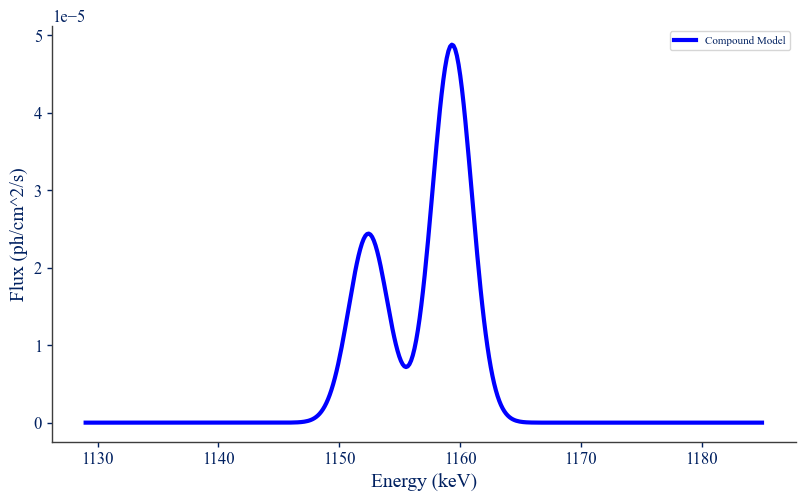

In [12]:
# Input .source values
F1 = 1e-4 / u.cm / u.cm / u.s
# mu1 = (1157-7.65) * u.keV
# sigma1 = np.sqrt(3.85**2 + 5.3**2) * u.keV / 2.355
mu1 = 1152.41 * u.keV
sigma1 = 3.85 * u.keV / 2.355

F2 = 2 * F1
# mu2 = (1157+3.89) * u.keV
mu2 = 1159.34 * u.keV
sigma2 = sigma1

# Define the first Gaussian
gaussian1 = Gaussian()
gaussian1.F.value = F1.value
gaussian1.F.min_value = F1.value / 1e3
gaussian1.F.max_value = F1.value * 1e3
gaussian1.F.unit = F1.unit
gaussian1.mu.value = mu1.value
gaussian1.mu.min_value = mu1.value - 10
gaussian1.mu.max_value = mu1.value + 10
gaussian1.mu.unit = mu1.unit
gaussian1.sigma.value = sigma1.value
gaussian1.sigma.min_value = sigma1.value - 5
gaussian1.sigma.max_value = sigma1.value + 5
gaussian1.sigma.unit = sigma1.unit

# Define the second Gaussian
gaussian2 = Gaussian()
gaussian2.F.value = F2.value
gaussian2.F.min_value = F2.value / 1e3
gaussian2.F.max_value = F2.value * 1e3
gaussian2.F.unit = F2.unit
gaussian2.mu.value = mu2.value
gaussian2.mu.min_value = mu2.value - 10
gaussian2.mu.max_value = mu2.value + 10
gaussian2.mu.unit = mu2.unit
gaussian2.sigma.value = sigma2.value
gaussian2.sigma.min_value = sigma2.value - 5
gaussian2.sigma.max_value = sigma2.value + 5
gaussian2.sigma.unit = sigma2.unit

gaussian1.F.free = False
gaussian1.mu.free = False
gaussian1.sigma.free = False
gaussian2.F.free = True
gaussian2.mu.free = False
gaussian2.sigma.free = False

# Create the compound model
spectrum = gaussian1 + gaussian2

# Generate some data for plotting
x_data = np.linspace(src.energy_bins[0], src.energy_bins[-1], 400)
y_data = spectrum(x_data)

# Plot the compound model
plt.plot(x_data, y_data, label="Compound Model")
plt.xlabel("Energy (keV)")
plt.ylabel("Flux (ph/cm^2/s)")
plt.legend()
plt.show()

In [46]:
F_param = Parameter('F', F1.value, F1.value/1e3, F1.value*1e3)
spectrum.F_1.link = F_param
spectrum.F_2.link = "F1.value + F2.value - F_param"

In [ ]:
isinstance(spectrum.F_1, type(F_param))

True

In [ ]:
CasA_astromodel = PointSource('CasA', spectral_shape=spectrum, 
                           l=target_coord.l.value,
                           b=target_coord.b.value)

Model_astromodel = Model(CasA_astromodel)

cosi.set_model(Model_astromodel)
plugins = DataList(cosi)        # 'cosi': COSI's 3ML plugin. If there are multiple instruments, we input a list of those instrument plugins here
like = JointLikelihood(Model_astromodel, plugins, verbose = False)

18:44:13 INFO      set the minimizer to minuit                                             ]8;id=789049;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=906289;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py#1045\1045]8;;\

In [16]:
Model_astromodel.free_parameters

OrderedDict([('CasA.spectrum.main.composite.F_1',
              Parameter F_1 = 0.0001 [1 / (s cm2)]
              (min_value = 1.0000000000000001e-07, max_value = 0.1, delta = 0.1, free = True)),
             ('CasA.spectrum.main.composite.F_2',
              Parameter F_2 = 0.0002 [1 / (s cm2)]
              (min_value = 2.0000000000000002e-07, max_value = 0.2, delta = 0.1, free = True))])

In [60]:
like.fit(quiet=True)

Adding 1e-12 to each bin of the expectation to avoid log-likelihood = -inf.


18:44:16 WARNING   get_number_of_data_points not implemented, values for statistical        ]8;id=880141;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/plugin_prototype.py\plugin_prototype.py]8;;\:]8;id=595972;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/plugin_prototype.py#130\130]8;;\
                  measurements such as AIC or BIC are unreliable                                                   

18:44:16 WARNING   The current value of the parameter F_1 (1.0) was above the new maximum 0.1.     ]8;id=775932;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=127188;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu_1 (0.0) was below the new minimum         ]8;id=889855;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=65571;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\
                  1139.35.                                                                                         

         WARNING   The current value of the parameter F_2 (1.0) was above the new maximum 0.2.     ]8;id=337626;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=841639;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu_2 (0.0) was below the new minimum         ]8;id=948549;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=431526;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\
                  1150.89.                                                                                         

(                                     value  negative_error  positive_error  \
 CasA.spectrum.main.composite.F_2  0.000998       -0.000014        0.000014   
 
                                      error         unit  
 CasA.spectrum.main.composite.F_2  0.000014  1 / (s cm2)  ,
        -log(likelihood)
 cosi     -168723.494712
 total    -168723.494712)

In [316]:
like.get_errors()


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in lo

,result,unit
parameter,,
CasA.spectrum.main.Gaussian.F,(3.7 +/- 0.8) x 10^-4,1 / (s cm2)
CasA.spectrum.main.Gaussian.sigma,1.1 -3.4 +5,keV


,value,negative_error,positive_error,error,unit
CasA.spectrum.main.Gaussian.F,0.000374,-0.000083,0.000083,0.000083,1 / (s cm2)
CasA.spectrum.main.Gaussian.sigma,1.142307,-3.428418,5.492513,4.460466,keV


In [322]:
like.results.analysis_type

'MLE'

In [18]:
like.results.covariance_matrix

array([[ 3.04171757e-06, -3.89727777e-07],
       [-3.89727777e-07,  5.01347907e-08]])

In [19]:
like.results.optimized_model

18:24:51 WARNING   The current value of the parameter F_1 (1.0) was above the new maximum 0.1.     ]8;id=532207;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=419537;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu_1 (0.0) was below the new minimum         ]8;id=705387;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=728558;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\
                  1139.35.                                                                                         

         WARNING   The current value of the parameter F_2 (1.0) was above the new maximum 0.2.     ]8;id=490150;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=366596;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu_2 (0.0) was below the new minimum         ]8;id=748874;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=706171;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\
                  1150.89.                                                                                         

Model summary:
==============

                  N
Point sources     1
Extended sources  0
Particle sources  0

Free parameters (2):
--------------------

                                     value min_value max_value      unit
CasA.spectrum.main.composite.F_1  0.006564       0.0       0.1  s-1 cm-2
CasA.spectrum.main.composite.F_2  0.000168       0.0       0.2  s-1 cm-2

Fixed parameters (6):
(abridged. Use complete=True to see all fixed parameters)


Properties (0):
--------------------

(none)


Linked parameters (0):
----------------------

(none)

Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

In [20]:
like.results.get_statistic_frame()

,-log(likelihood)
cosi,-168723.494716
total,-168723.494716


In [325]:
like.results.get_flux(ene_min = 1 * u.MeV, ene_max = 1.2 * u.MeV)

15:25:41 WARNING   The current value of the parameter F (1.0) was above the new maximum 0.3.       ]8;id=938386;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=61662;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu (0.0) was below the new minimum 1147.0.   ]8;id=626716;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=312541;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

processing MLE analyses:   0%|          | 0/1 [00:00<?, ?it/s]

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.3.       ]8;id=310092;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=395408;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu (0.0) was below the new minimum 1147.0.   ]8;id=970839;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=568452;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

,flux,low bound,hi bound
CasA: total,4.813136439691445e-10 erg / (s cm2),-4.954229725391686e-10 erg / (s cm2),8.202307297087927e-10 erg / (s cm2)


In [234]:
like._record_calls

{(0.0003742201929233492, 1.1423065283429086): 169135.7315576608,
 (0.0003763488137727744, 1.1423065283429086): 169135.64998076612,
 (0.00037209760618642804, 1.1423065283429086): 169135.6500877278,
 (0.0003757166450884658, 1.1423065283429086): 169135.69121385447,
 (0.00037272672550707687, 1.1423065283429086): 169135.69125102728,
 (0.0003742201929233492, 1.1487950461275371): 169135.7311791918,
 (0.0003742201929233492, 1.1358188479858526): 169135.73119987568,
 (0.0003742201929233492, 1.2072275696077623): 169135.68346916593,
 (0.0003742201929233492, 1.077469228660628): 169135.70412699078,
 (0.0003742198484004838, 1.1334334064740172): 169135.7308977002,
 (0.00037422007551176956, 1.1392824380127573): 169135.7314790263,
 (0.00037422014245978304, 1.1410067503993684): 169135.73154302576,
 (0.0003742201693582396, 1.1416995632567675): 169135.73155445998,
 (0.00037422018151858345, 1.1420127754059486): 169135.7315569101,
 (0.00037422018731106085, 1.1421619721677239): 169135.73155747884,
 (0.0003742

Profiling likelihood:   0%|          | 0/3 [00:00<?, ?it/s]

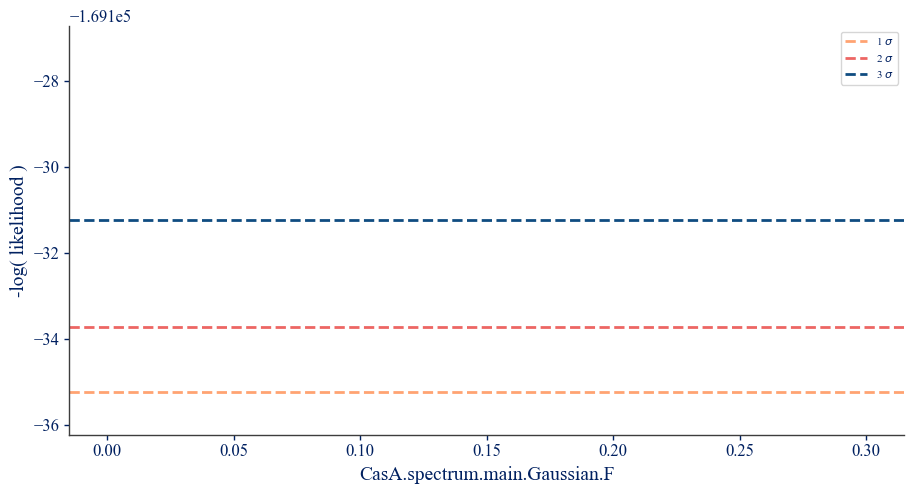

In [275]:
param1 = spectrum.parameters['F']
param2 = spectrum.parameters['sigma']
contour = like.get_contours(param1, param1.min_value, param1.max_value, 3)

In [303]:
like.results._optimal_statistic_values

cosi   -169135.731558
dtype: float64

In [ ]:
param1.path

'CasA.spectrum.main.Gaussian.F'

In [312]:
like.results.get_variates(param1.path)

equal-tail: (3.8 -0.6 +0.7) x 10^-4, hpd: (3.8 +/- 0.6) x 10^-4

In [315]:
spectrum.path

'CasA.spectrum.main.Gaussian'

In [332]:
for par in spectrum.parameters.values():
    if par.free:
        print(par.path)

CasA.spectrum.main.Gaussian.F
CasA.spectrum.main.Gaussian.sigma


In [61]:
# Summary of results
results = like.results

parameters = {par.name:results.get_variates(par.path)                           # Exactly as given in https://threeml.readthedocs.io/en/stable/notebooks/Analysis_results_showcase.html#Error-propagation
              for par in results.optimized_model['CasA'].parameters.values()
              if par.free}

results_error_propagator_function = results.propagate(results.optimized_model['CasA'].spectrum.main.shape.evaluate_at, **parameters)

18:44:23 WARNING   The current value of the parameter F_1 (1.0) was above the new maximum 0.1.     ]8;id=205385;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=298773;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu_1 (0.0) was below the new minimum         ]8;id=205058;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=771434;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\
                  1139.35.                                                                                         

         WARNING   The current value of the parameter F_2 (1.0) was above the new maximum 0.2.     ]8;id=154158;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=225042;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu_2 (0.0) was below the new minimum         ]8;id=833620;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=934700;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\
                  1150.89.                                                                                         

         WARNING   The current value of the parameter F_1 (1.0) was above the new maximum 0.1.     ]8;id=41811;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=970384;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu_1 (0.0) was below the new minimum         ]8;id=76564;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=300697;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\
                  1139.35.                                                                                         

         WARNING   The current value of the parameter F_2 (1.0) was above the new maximum 0.2.     ]8;id=166982;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=724292;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu_2 (0.0) was below the new minimum         ]8;id=83129;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=735463;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\
                  1150.89.                                                                                         

In [54]:
results_error_propagator_function(1157)

equal-tail: (3.14 +/- 0.04) x 10^-5, hpd: (3.14 +/- 0.04) x 10^-5

In [24]:
parameters['F_1'] + parameters['F_2']

equal-tail: (6.3 -1.3 +1.0) x 10^-3, hpd: (6.3 -0.7 +1.5) x 10^-3

In [367]:
type(like.results)

threeML.analysis_results.MLEResults

In [196]:
type(results.optimized_model['CasA'])

14:33:22 WARNING   The current value of the parameter F (1.0) was above the new maximum 0.3.       ]8;id=918923;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=60885;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu (0.0) was below the new minimum 1147.0.   ]8;id=705613;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=298897;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

astromodels.sources.point_source.PointSource

In [62]:
results.display()

Best fit values:

,result,unit
parameter,,
CasA.spectrum.main.composite.F_2,(9.98 +/- 0.14) x 10^-4,1 / (s cm2)


Correlation matrix:

1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-168723.494712
total,-168723.494712


Values of statistical measures:

,statistical measures
AIC,-337448.989425
BIC,-337446.989425


In [63]:
energies = np.linspace(src.energy_bins[0], src.energy_bins[-1], 113)        # Also taken from https://threeml.readthedocs.io/en/stable/notebooks/Analysis_results_showcase.html#Error-propagation

flux_low = np.zeros_like(energies)
flux_median = np.zeros_like(energies)
flux_high = np.zeros_like(energies)

p = tqdm(total=len(energies), desc='Propagating errors')
# Evaluate flux
for i, e in enumerate(energies):
    this_flux = results_error_propagator_function(e)
    # flux_low[i], flux_high[i] = this_flux.equal_tail_interval(cl=0.68)       # 1-sigma bounds, default (without argument) returns 1-sigma
    # Alternately,
    flux_low[i], flux_high[i] = this_flux.highest_posterior_density_interval(cl=0.68)
    flux_median[i] = this_flux.median

    p.update(1)

Propagating errors:  99%|█████████▉| 112/113 [00:07<00:00, 14.96it/s]

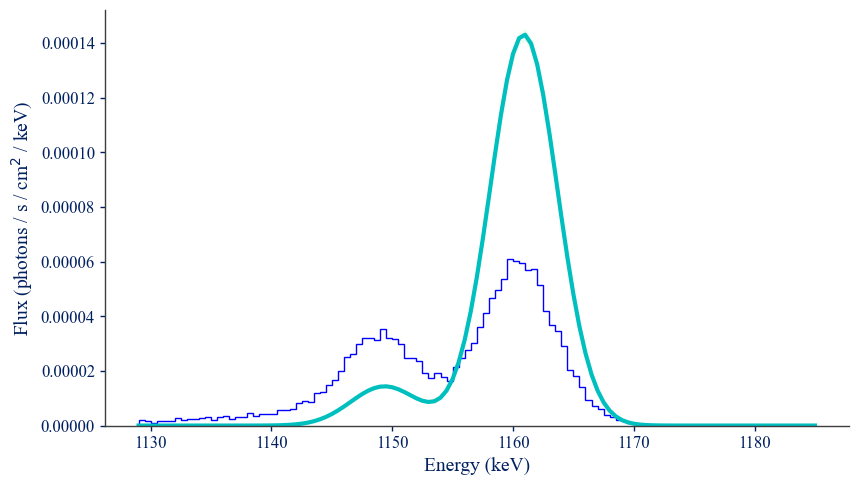

Propagating errors: 100%|██████████| 113/113 [00:23<00:00, 14.96it/s]

In [ ]:
obs_duration = 93 * 86400       # seconds
Aeff = 3                      # cm**2

source = UnBinnedData("inputs.yaml")
source.data_file = str(DATA_DIR / f'44Ti/sources/{name}_3months_unbinned_data_filtered_with_SAAcut.fits')
this_dict = source.get_dict_from_fits(source.data_file)

counts, _ = np.histogram(this_dict['Energies'], bins=energies)
# plt.stairs(counts / counts.sum() / np.diff(energies), energies)
plt.stairs(counts / np.diff(energies) / obs_duration / Aeff, energies)     # Plots observed counts / binwidth       (photons / sec / cm**2 / keV)

plt.plot(energies, flux_median, c='c')      # Plots physical value Flux     (photons / sec / cm**2 / keV)
plt.fill_between(energies, flux_low, flux_high, alpha=0.1, color='lightgreen')

plt.ylabel('Flux (photons / s / cm$^{2}$ / keV)')
plt.xlabel('Energy (keV)')
# plt.yscale('log')
plt.show()

#### 3ML Tutorial Snippets